## Make Figures
This notebook is for making figures used for slides

In [1]:
import sys
sys.path.append('../src')

import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/lambda_5000000_1


TypeError: 'NoneType' object is not subscriptable

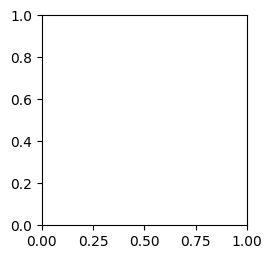

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 128
lambda_1 = 5000000
lambda_2 = 1
num_collocation = 1000
num_layers = 2
steps_to_visualize = [0, 100, 10000]
steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = "../data/synthetic/biconcave.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Plot figures
fig = plt.figure(figsize=(9, 6))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(2, 3, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=64, axis="z", no_label=True)

# Row 2: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(2, 3, 3 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, no_label=True)
    
plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/experimental/TS_105_7/lambda_1000000_100


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resizing MRC data from (64, 64, 64) to (128, 128, 128)


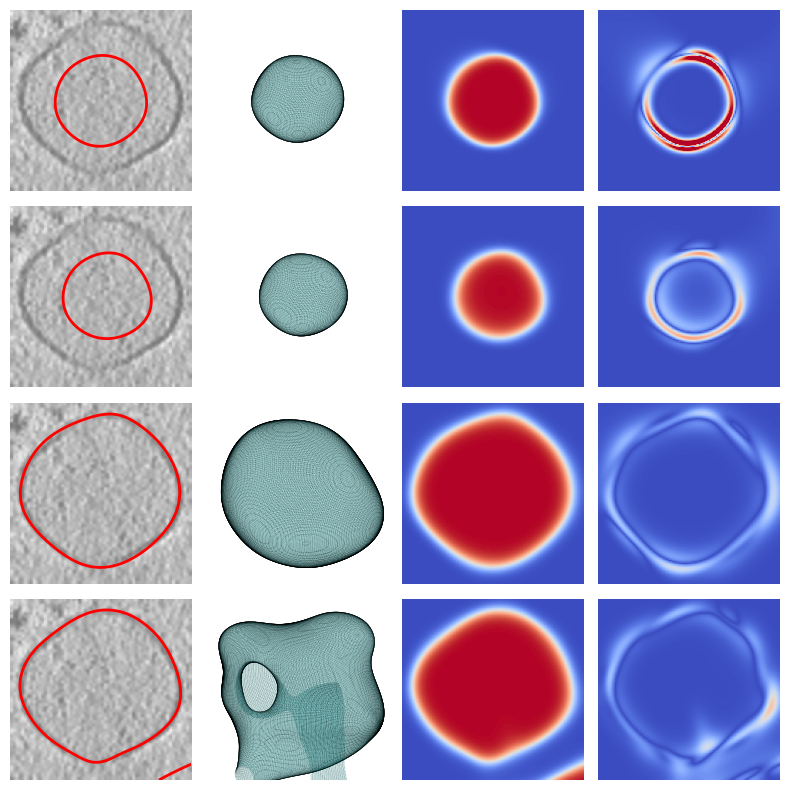

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 128
lambda_1 = 1000000
lambda_2 = 100
num_collocation = 1000
num_layers = 2
steps_to_visualize = [0, 100, 1000, 10000]
steps_series = list(range(0, 10001, 100))
epsilon = 0.05

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/TS_105_7/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
# mrc_file_path = "../data/synthetic/biconcave.mrc"
mrc_file_path = "../data/experimental/downsampled/TS_105_7.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

col_len = len(steps_to_visualize)

fig = plt.figure(figsize=(2*4, 2*col_len))  # width × height in inches

for i, step in enumerate(steps_to_visualize):
    # Column 1: CryoET with contours
    ax1 = fig.add_subplot(col_len, 4, i*4 + 1)
    visualize_cryoET_with_contours(ax1, step, checkpoint_data[step], cryoET_data,
                                   grid_size=GRID_SIZE, slice_index=64, axis="x", no_label=True)

    # Column 2: 3D Isosurface
    ax2 = fig.add_subplot(col_len, 4, i*4 + 2, projection='3d')
    plot_3d_isosurface(ax2, step, checkpoint_data[step], grid_size=GRID_SIZE, no_label=True)

    # Column 3: Placeholder for your 3rd plot type
    ax3 = fig.add_subplot(col_len, 4, i*4 + 3)
    ax3 = visualize_physics_loss(ax3, epsilon=epsilon, 
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=64, axis="x", vmin=-1, vmax=1, no_label=True)

    # Column 4: Placeholder for your 4th plot type
    ax4 = fig.add_subplot(col_len, 4, i*4 + 4)
    ax4 = visualize_physics_loss(ax4, epsilon=epsilon, 
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=64, axis="x", vmin=0, vmax=150, no_label=True)

plt.tight_layout()
# plt.savefig("your_filename.png", dpi=300, bbox_inches="tight")
plt.show()



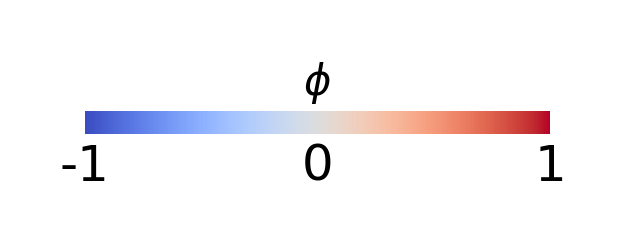

In [16]:
# standalone color bar

import matplotlib.pyplot as plt
import matplotlib.colorbar as colorbar
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig_type = "phi"

if fig_type == "tension":
    vmin = 0
    vmax = 400
elif fig_type == "bend":
    vmin = 0
    vmax = 150
elif fig_type == "phi":
    vmin = -1
    vmax = 1

# Create a dummy ScalarMappable with a colormap and normalization
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.coolwarm  # or any other colormap, e.g., cm.coolwarm
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

# Create a standalone figure just for the colorbar

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    
    # horizontal setup
    fig, ax = plt.subplots(figsize=(1, 0.1))  # Adjust size as needed
    fig.subplots_adjust(bottom=0.5)  # Make space for horizontal colorbar
    cbar = fig.colorbar(sm, cax=ax, orientation='horizontal')

    # cbar.set_label(r"$\phi$", fontsize=23)
    if fig_type == "tension":
        cbar.set_label(r"$\epsilon|\nabla\phi|^2 + (1/2\epsilon) (1-\phi^2)^2$", labelpad=2, fontsize=5)
    elif fig_type == "bend":
        cbar.set_label(r"$|\epsilon\Delta \phi - (1/\epsilon)(\phi^2 - 1)\phi|$", labelpad=2, fontsize=5)
    elif fig_type == "phi":
        cbar.set_label(r"$\phi$", labelpad=2, fontsize=5)

    cbar.ax.xaxis.set_label_position('top')
    
    
    # # vertical setup
    # fig, ax = plt.subplots(figsize=(0.05, 0.5))  # Adjust size as needed
    # cbar = fig.colorbar(sm, cax=ax, orientation='vertical')
    # cbar.set_label(r"$\phi$", rotation=0, labelpad=2)
    # cbar.ax.yaxis.set_label_position('right')
    
    
    # cbar.ax.tick_params(labelsize=20)
    cbar.ax.tick_params(axis='x', which='both', length=0)
    cbar.ax.tick_params(axis='y', which='both', length=0)
    cbar.set_ticks([vmin, 0, vmax])

    
    # Remove border lines (spines)
    for spine in cbar.ax.spines.values():
        spine.set_visible(False)

    # plt.savefig(f"../outputs/figs/sync/cbar_{fig_type}_2.png", bbox_inches="tight")
    plt.show()


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0926/clean/lambda_1000000_0


/tmp/ipykernel_71029/2281933528.py:51: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rx" (-> color='r'). The keyword argument will take precedence.
  ax.plot(s, data_loss_norm[idx], 'rx', markersize=10, markeredgewidth=2, color = "black")
/tmp/ipykernel_71029/2281933528.py:67: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rx" (-> color='r'). The keyword argument will take precedence.
  ax.plot(s, physics_loss_norm[idx], 'rx', markersize=10, markeredgewidth=2, color = "black")


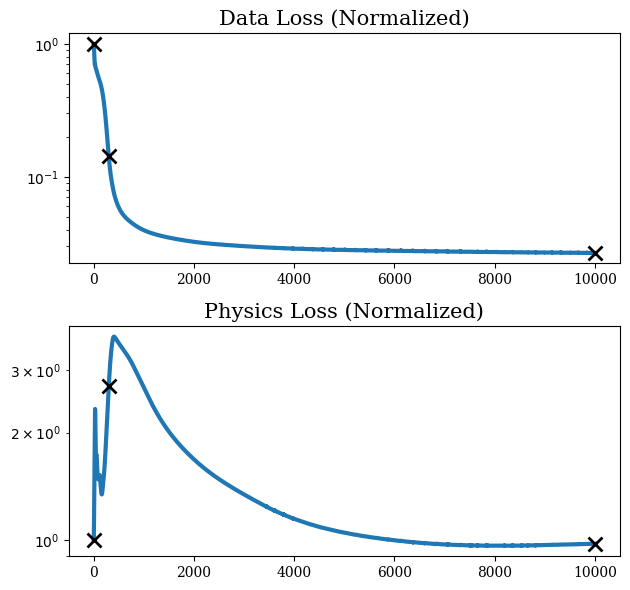

In [16]:
# Loss term progress plot

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
# from pinn.plot import (
    # plot_loss_history_ax,
    # plot_normalized_loss_history_ax,
# )
from pinn.utils import assemble_loss_history



lambda_1 = 1000000
lambda_2 = 0
steps_series = list(range(0, 10001, 100))
mark_steps = [0, 300, 10000]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/data_0926/clean/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

assembled_loss = assemble_loss_history(checkpoint_data)
data_loss_norm = assembled_loss["data_loss"] / assembled_loss["data_loss"][0]
physics_loss_norm = assembled_loss["physics_loss"] / assembled_loss["physics_loss"][0]
total_loss_norm = assembled_loss["total_loss"] / assembled_loss["total_loss"][0]

step_array = assembled_loss["step"]
mark_indices = {s: np.where(step_array == s)[0][0] for s in mark_steps if s in step_array}


# fig = plt.figure(figsize=(3.8*1, 3*2))  # width × height in inches
fig = plt.figure(figsize=(3.2*2, 3*2))  # width × height in inches

ax = fig.add_subplot(2, 1, 1)
ax.plot(assembled_loss["step"], data_loss_norm, linestyle='-', linewidth=3)
ax.set_yscale('log')
ax.set_title("Data Loss (Normalized)", fontsize=15, family="serif")
# ax.set_xlabel("Steps", family="serif")
# ax.xaxis.set_label_coords(1.04, -0.04)
# ax.grid(True, which='both', linestyle='--', linewidth=0.5)

for s, idx in mark_indices.items():
    ax.plot(s, data_loss_norm[idx], 'rx', markersize=10, markeredgewidth=2, color = "black")

for label in ax.get_xticklabels():
    label.set_fontfamily("serif")
# for label in ax.get_yticklabels():
#     label.set_fontfamily("serif")

ax = fig.add_subplot(2, 1, 2)
ax.plot(assembled_loss["step"], physics_loss_norm, linestyle='-', linewidth=3)
ax.set_yscale('log')
ax.set_title("Physics Loss (Normalized)", fontsize=15, family="serif")
# ax.set_xlabel("Steps", family="serif")
# ax.xaxis.set_label_coords(1.04, -0.04)
# ax.grid(True, which='both', linestyle='--', linewidth=0.5)

for s, idx in mark_indices.items():
    ax.plot(s, physics_loss_norm[idx], 'rx', markersize=10, markeredgewidth=2, color = "black")

for label in ax.get_xticklabels():
    label.set_fontfamily("serif")
# for label in ax.get_yticklabels():
    # label.set_fontfamily("serif")

plt.tight_layout()
# plt.savefig("../outputs/figs/loss_progress.png", dpi=600, bbox_inches="tight")
plt.show()



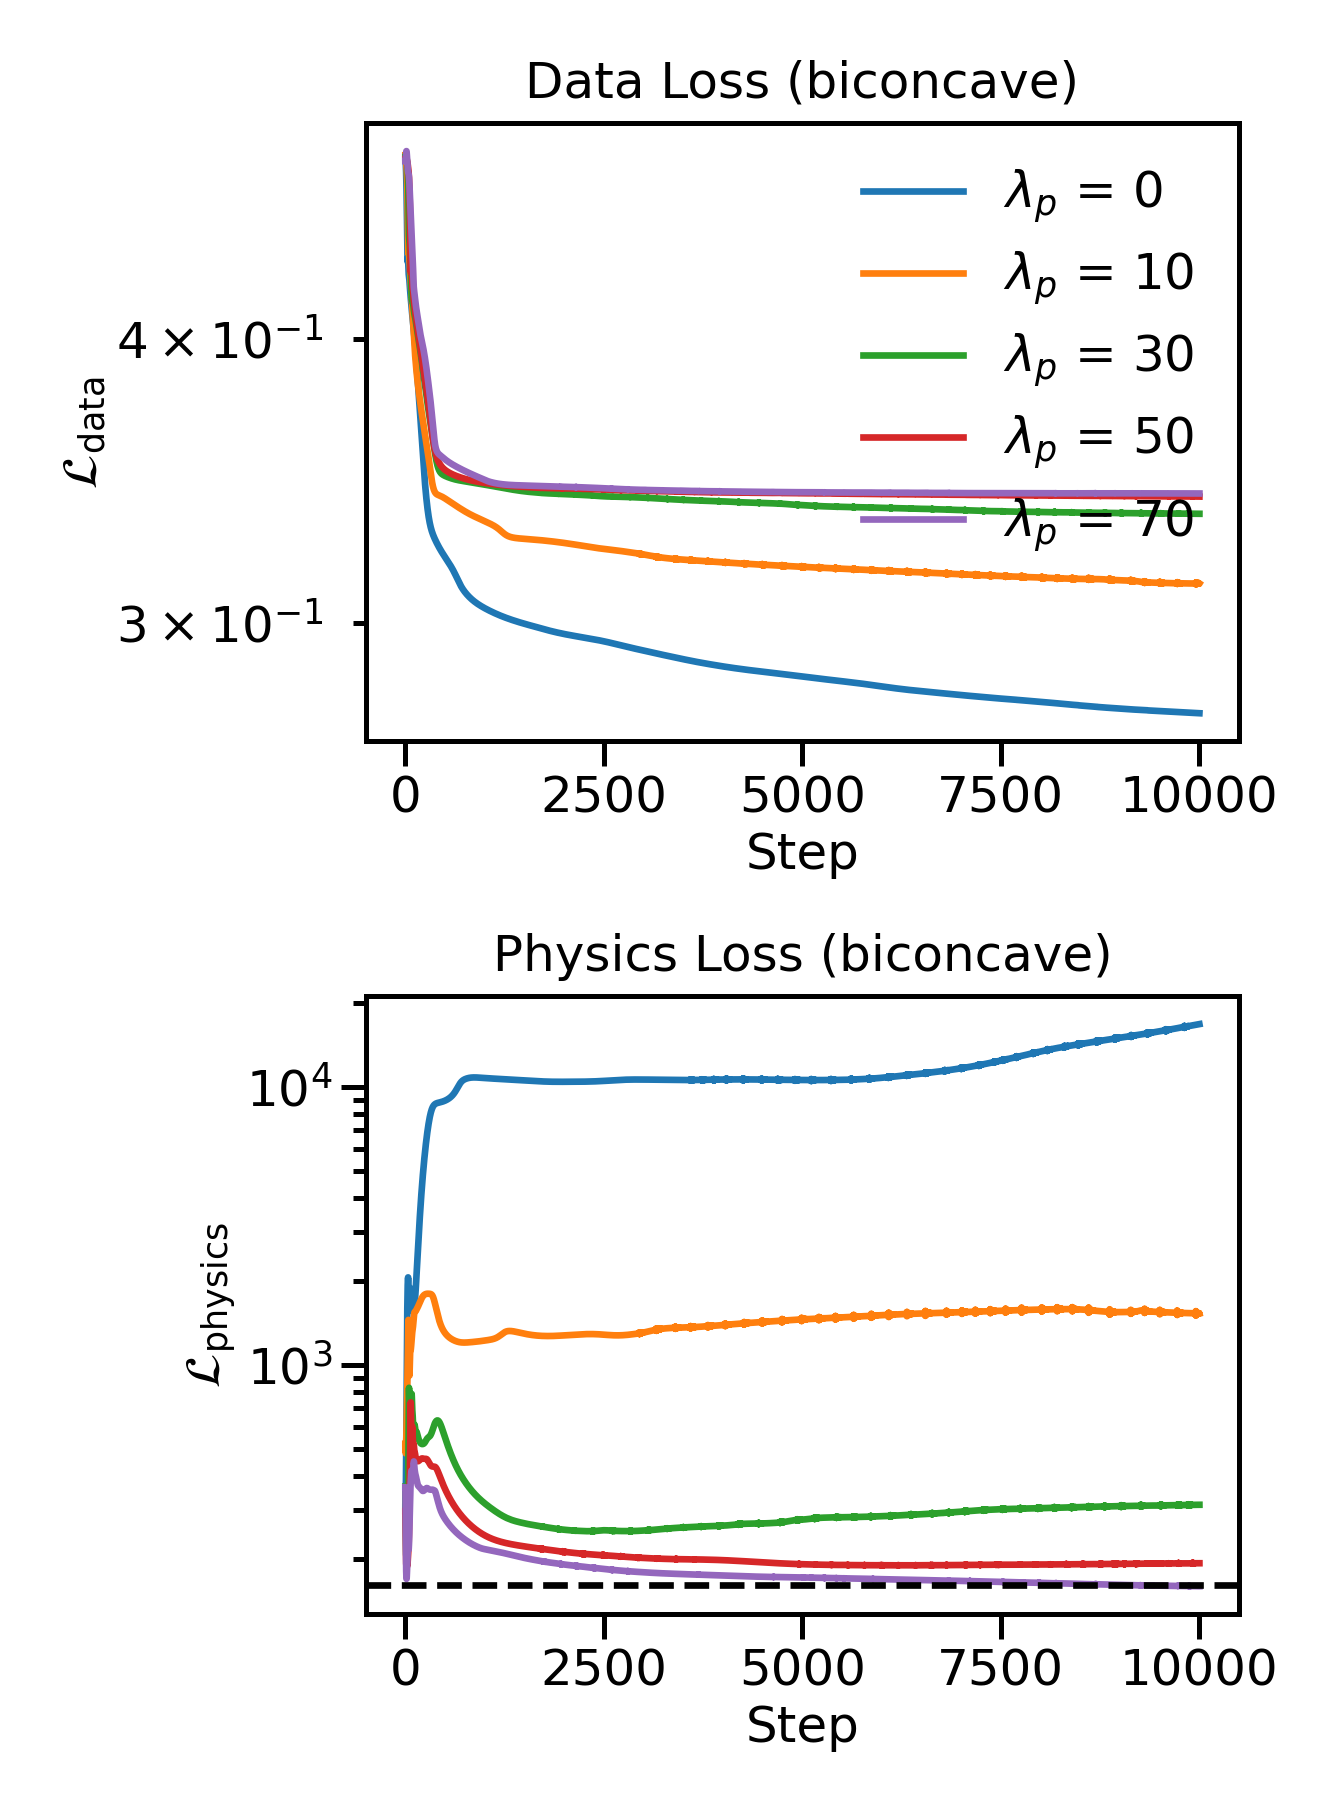

In [8]:
# Loss term progress (multiple plots)

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.utils import assemble_loss_history
import math


bend_mem = {
    "biconcave": 34.23409861449123,
    "bud":       21.941595635908413,
    "bud_04":    21.941595635908413,
    "multi":     30.912018724759164 + 25.420889021757755
}

lambda_1 = 1000000
lambda_2_list = [0, 10, 30, 50, 70]
steps_series = list(range(0, 10001, 100))
data_ver = "1115"
shape = "biconcave"
epsilon = 0.05
kappa = 1
V_box = 8
flip_ratio = 0.15
missing_ratio = 0.7
flip_str = str(flip_ratio).replace('.', '')
missing_str = str(missing_ratio).replace('.', '')

scale = 4 * math.sqrt(2) / 3 / kappa / epsilon / V_box
bend_mem = {key: val * scale for key, val in bend_mem.items()}


# Load checkpoint data
loss_data = {}
loss_phys = {}
for lambda_2 in lambda_2_list:
    # checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_ver}/clean/sphere/lambda_{lambda_1}_{lambda_2}")
    checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_ver}/combine/a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lambda_2}")
    checkpoint_data = {}
    for step in steps_series:
        checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

    assembled_loss = assemble_loss_history(checkpoint_data)
    loss_data[lambda_2] = assembled_loss["data_loss"]
    loss_phys[lambda_2] = assembled_loss["physics_loss"]

step_array = assembled_loss["step"]

# Plot
plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    fig, axes = plt.subplots(2, 1, figsize=(2.2, 3))
    
    # --- Data loss plot ---
    ax = axes[0]
    for lambda_2 in lambda_2_list:
        ax.plot(step_array, loss_data[lambda_2], label=fr"$\lambda_p$ = {lambda_2}")
    ax.set_yscale('log')
    ax.set_title(f"Data Loss ({shape})")
    ax.set_xlabel("Step")
    ax.set_ylabel(r"$\mathcal{L}_\mathrm{data}$")
    ax.legend(frameon=False)
    
    # --- Physics loss plot ---
    ax = axes[1]
    for lambda_2 in lambda_2_list:
        ax.plot(step_array, loss_phys[lambda_2], label=fr"$\lambda_p$ = {lambda_2}")
    ax.set_yscale('log')
    ax.set_title(f"Physics Loss ({shape})")
    ax.set_xlabel("Step")
    ax.set_ylabel(r"$\mathcal{L}_\mathrm{physics}$")
    ax.axhline(y=bend_mem[shape], color='black', linestyle='--')
    # ax.legend(frameon=False)
    
    plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/loss_progress_{shape}.pdf", bbox_inches="tight")
    plt.savefig(f"../outputs/figs/sync/noise/loss_progress_a{flip_str}_m{missing_str}_{shape}.pdf", bbox_inches="tight")
    plt.show()

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

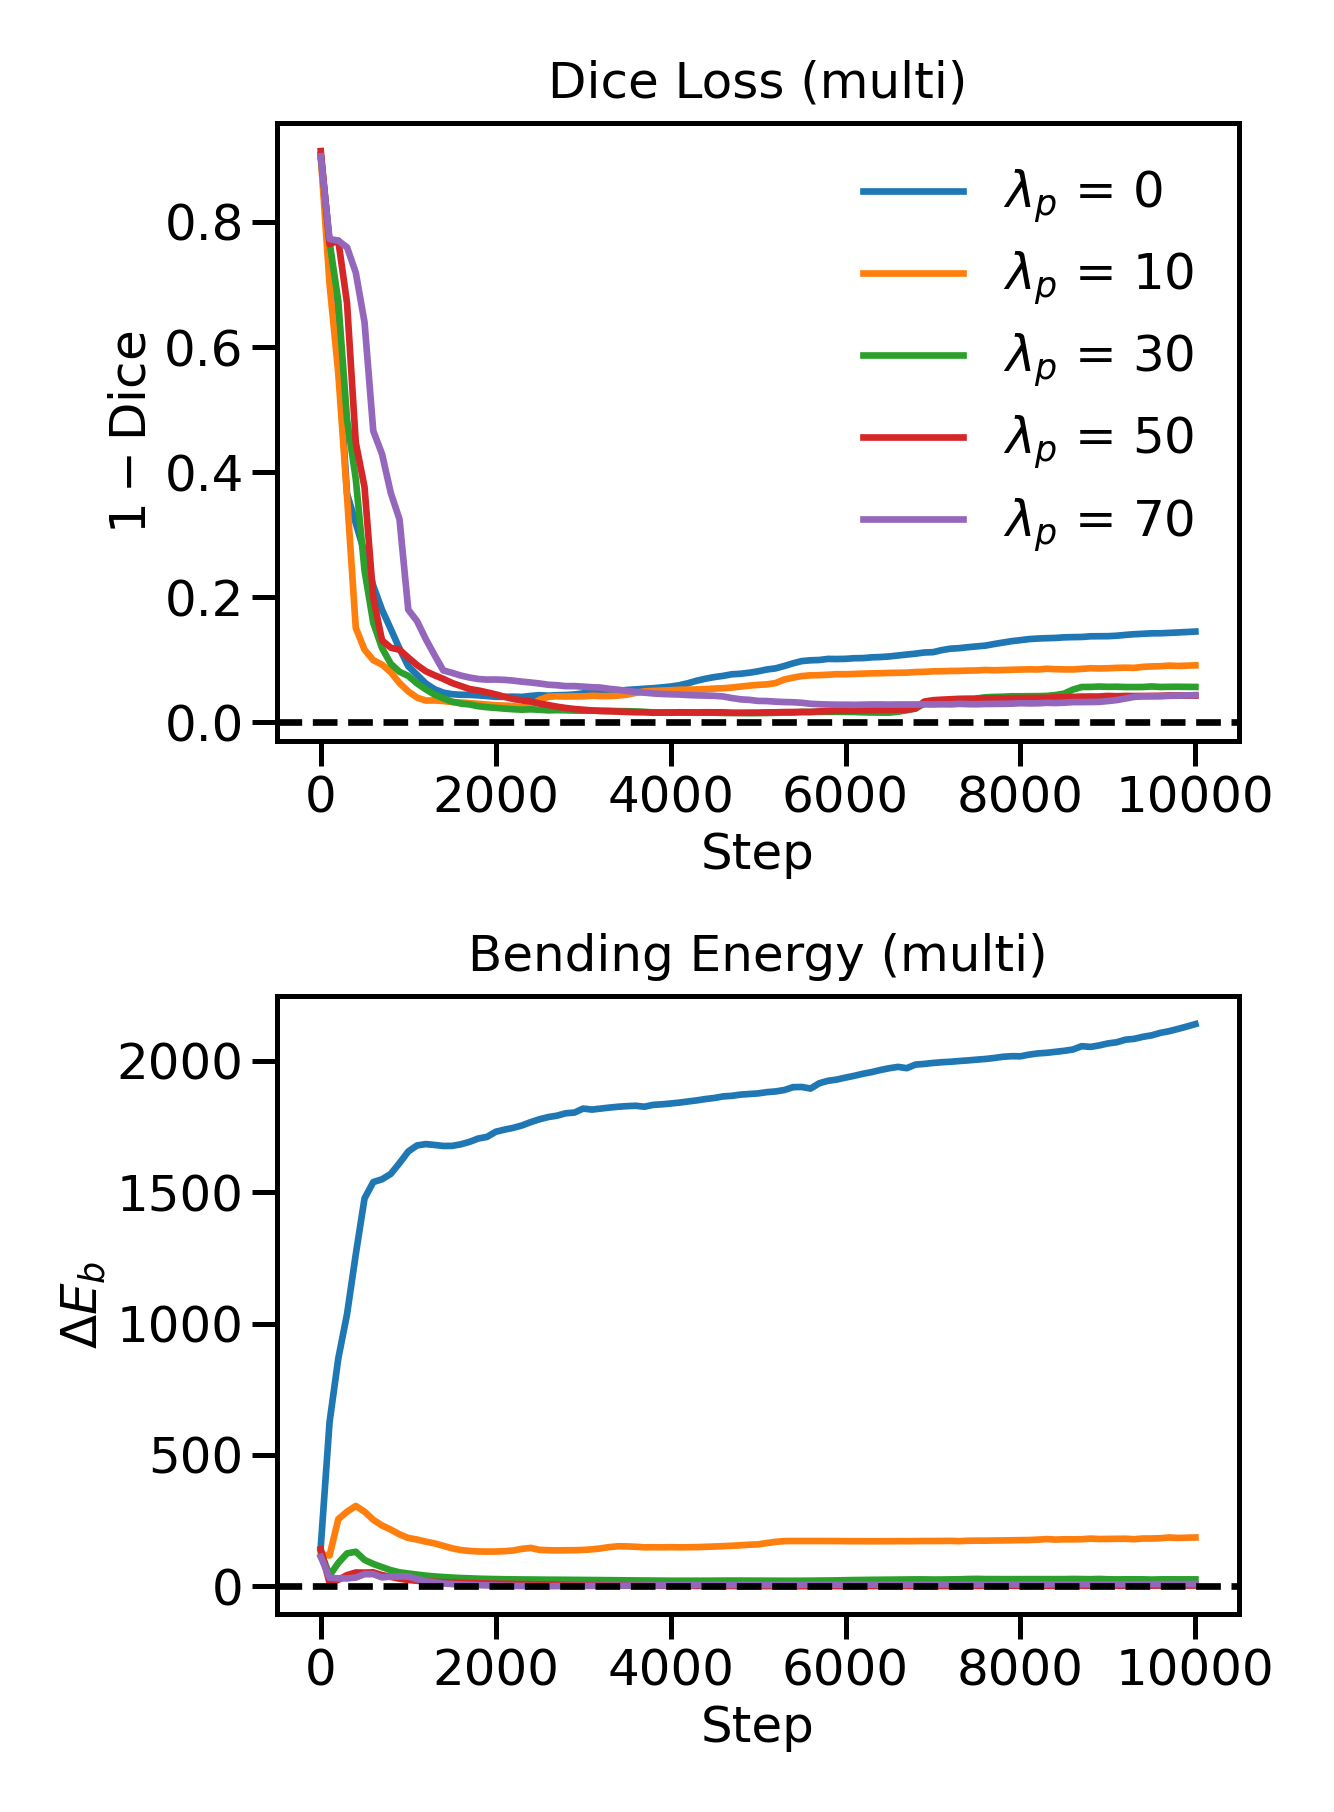

In [5]:
# Accuracy metrics progress (multiple plots)

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.utils import assemble_loss_history
import math
from pinn.analysis import surface_dice, calc_bend_seg
from tqdm.notebook import tqdm


bend_mem = {
    "biconcave": 34.23409861449123,
    "bud":       21.941595635908413,
    "bud_04":    21.941595635908413,
    "multi":     30.912018724759164 + 25.420889021757755
}

lambda_1 = 1000000
lambda_2_list = [0, 10, 30, 50, 70]
steps_series = list(range(0, 10001, 100))
data_ver = "1115"
shape = "multi"
epsilon = 0.05
kappa = 1
flip_ratio = 0.15
missing_ratio = 0.7
flip_str = str(flip_ratio).replace('.', '')
missing_str = str(missing_ratio).replace('.', '')

# Ground truth from MRC
mrc_path = f"../data/synthetic/{shape}.mrc"
bend_true = bend_mem[shape]

# Load checkpoint data
dice_loss = {}
bend_energy = {}

for lambda_2 in lambda_2_list:
    # checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_ver}/clean/sphere/lambda_{lambda_1}_{lambda_2}")
    checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{data_ver}/combine/a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lambda_2}")    

    dice_loss[lambda_2] = {}
    bend_energy[lambda_2] = {}

    for step in tqdm(steps_series):
        ckpt_dir = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        dat_seg = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)
        
        dice_val = surface_dice(mrc_path, dat_seg, grid_size=64, threshold=0.6, band_thickness=0.4)
        bend_seg_val = calc_bend_seg(dat_seg, epsilon=epsilon, kappa=kappa, sampling="random", num_point=10000)

        dice_loss[lambda_2][step] = float(dice_val)
        bend_energy[lambda_2][step] = float(abs(bend_true - bend_seg_val))


plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    fig, axes = plt.subplots(2, 1, figsize=(2.2, 3))

    # --- Data loss plot ---
    ax = axes[0]
    for lambda_2 in lambda_2_list:
        steps = np.array(sorted(dice_loss[lambda_2].keys()))
        vals = np.array([dice_loss[lambda_2][s] for s in steps])
        ax.plot(steps, vals, label=fr"$\lambda_p$ = {lambda_2}")

    ax.set_title(f"Dice Loss ({shape})")
    ax.set_xlabel("Step")
    ax.set_ylabel(r"$1 - \mathrm{Dice}$")
    ax.axhline(y=0, color="black", linestyle="--")
    ax.legend(frameon=False)

    # --- Physics loss plot ---
    ax = axes[1]
    for lambda_2 in lambda_2_list:
        steps = np.array(sorted(bend_energy[lambda_2].keys()))
        vals = np.array([bend_energy[lambda_2][s] for s in steps])
        ax.plot(steps, vals, label=fr"$\lambda_p$ = {lambda_2}")

    ax.set_title(f"Bending Energy ({shape})")
    ax.set_xlabel("Step")
    ax.set_ylabel(r"$\Delta E_b$")
    ax.axhline(y=0, color="black", linestyle="--")
    # ax.legend(frameon=False)

    plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/accuracy_progress_{shape}.pdf", bbox_inches="tight")
    plt.savefig(f"../outputs/figs/sync/noise/accuracy_progress_a{flip_str}_m{missing_str}_{shape}.pdf", bbox_inches="tight")
    plt.show()

In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history
import matplotlib.pyplot as plt

GRID_SIZE = 128
lambda_1 = 1000000
lambda_2_list = [0, 10, 100, 1000]
epsilon = 0.05
step = 1000

# Load checkpoint data
checkpoint_data = {}
for lambda_2 in lambda_2_list:
    checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/TS_105_7/lambda_{lambda_1}_{lambda_2}")
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
# mrc_file_path = "../data/synthetic/biconcave.mrc"
mrc_file_path = "../data/experimental/downsampled/TS_105_7.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)


n = len(lambda_2_list)
fig = plt.figure(figsize=(2*n, 2*4))  # Adjust height accordingly


for i, lambda_2 in enumerate(lambda_2_list):
    # Column 1: CryoET with contours
    ax1 = fig.add_subplot(4, 4, i*4 + 1)
    visualize_cryoET_with_contours(ax1, step, checkpoint_data[lambda_2], cryoET_data,
                                   grid_size=GRID_SIZE, slice_index=64, axis="x", no_label=True)

    # Column 2: 3D Isosurface
    ax2 = fig.add_subplot(4, 4, i*4 + 2, projection='3d')
    plot_3d_isosurface(ax2, step, checkpoint_data[lambda_2], grid_size=GRID_SIZE, no_label=True)

    # Column 3: Placeholder for your 3rd plot type
    ax3 = fig.add_subplot(4, 4, i*4 + 3)
    ax3 = visualize_physics_loss(ax3, epsilon=epsilon, 
                           checkpoint=checkpoint_data[lambda_2], component="phi",
                           grid_size=GRID_SIZE, slice_index=64, axis="x", vmin=-1, vmax=1, no_label=True)

    # Column 4: Placeholder for your 4th plot type
    ax4 = fig.add_subplot(4, 4, i*4 + 4)
    ax4 = visualize_physics_loss(ax4, epsilon=epsilon, 
                           checkpoint=checkpoint_data[lambda_2], component="residual",
                           grid_size=GRID_SIZE, slice_index=64, axis="x", vmin=0, vmax=150, no_label=True)


plt.tight_layout()
# plt.savefig("your_filename.png", dpi=300, bbox_inches="tight")
plt.show()



/gscratch/matsulab/envs/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
ERROR:root:Device TFRT_CPU_0 was not found in jax.local_devices().
ERROR:root:Device TFRT_CPU_0 was not found in jax.local_devices().
ERROR:root:Device TFRT_CPU_0 was not found in jax.local_devices().
ERROR:root:Device TFRT_CPU_0 was not found in jax.local_devices().
ERROR:root:Device TFRT_CPU_0 was not found in jax.local_devices().
ERROR:root:Device TFRT_CPU_0 was not found in jax.local_devices().
ERROR:root:Device TFRT_CPU_0 was not found in jax.local_devices().
ERROR:root:Device TFRT_CPU_0 was not found in jax.local_devices().
ERROR:root:Device TFRT_CPU_0 wa

ValueError: sharding passed to deserialization should be specified, concrete and an instance of `jax.sharding.Sharding`. Got None

Resizing MRC data from (128, 128, 128) to (64, 64, 64)


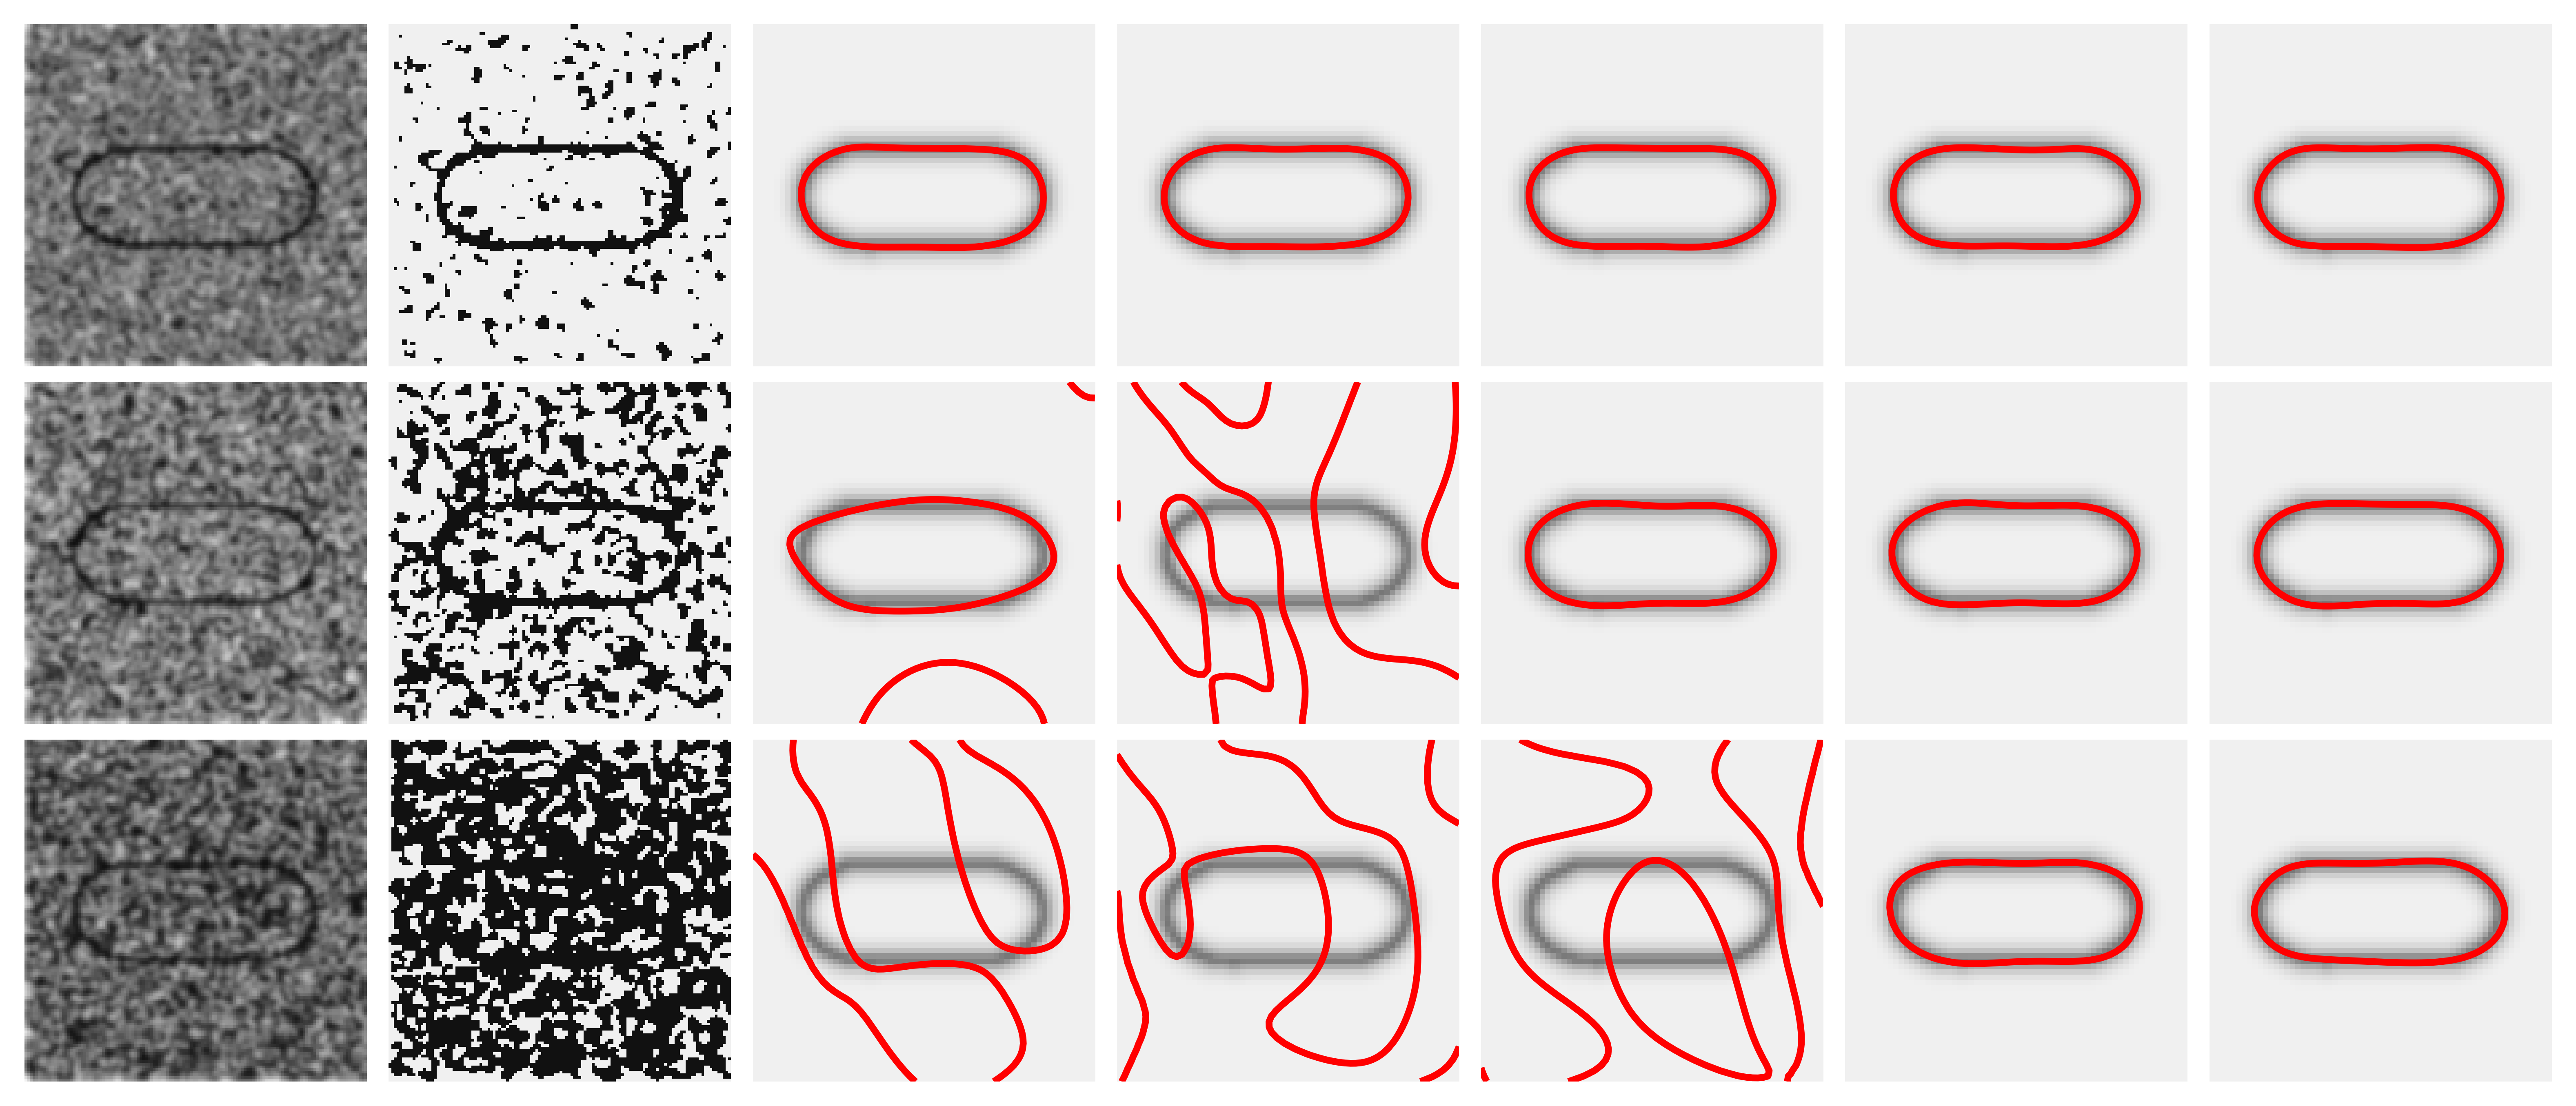

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile
import jax
import jax.numpy as jnp


GRID_SIZE = 64
lambda_1 = 1000000
lambda_2_list = [0, 10, 30, 50, 70]
flip_ratio_list = [0.1, 0.15, 0.2]
step = 20000 #10000
thre = 0.8
shape = "biconcave"
data_type = "data_1027"
# data_type = "data_0926"


# Load checkpoint data
checkpoint_data = {}
for lambda_2 in lambda_2_list:
    checkpoint_data[lambda_2] = {}
    for flip_ratio in flip_ratio_list:
        flip_str = str(flip_ratio).replace('.', '')
        checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/f{flip_str}/lambda_{lambda_1}_{lambda_2}")
        checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        checkpoint_data[lambda_2][flip_ratio] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load input data
input_data = {}
for flip_ratio in flip_ratio_list:
    flip_str = str(flip_ratio).replace('.', '')
    input_file = f"../data/synthetic/flip_noise/{shape}_f{flip_str}.mrc"
    with mrcfile.open(input_file, permissive=True) as mrc:
        volume = mrc.data
    input_data[flip_ratio] = volume

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    n = len(lambda_2_list)       # lambda_2 columns
    m = len(flip_ratio_list)     # flip_ratio rows
    n_col = n+2
    fig = plt.figure(figsize=(1.5*n_col, 1.5*m))
    
    for i, flip_ratio in enumerate(flip_ratio_list):      # rows
    
        ax = fig.add_subplot(m, n_col, i * n_col + 1)  # First column in row
        plot_single_slice(input_data[flip_ratio], ax=ax, axis="z", slice_index=64, thre=None, show_title=False)
    
        ax = fig.add_subplot(m, n_col, i * n_col + 2)  # Second column in row
        plot_single_slice(input_data[flip_ratio], ax=ax, axis="z", slice_index=64, thre=0.8, show_title=False) 
    
        for j, lambda_2 in enumerate(lambda_2_list):      # columns
            ax = fig.add_subplot(m, n_col, i * n_col + j + 3)
            data = checkpoint_data[lambda_2][flip_ratio]
    
            if data is not None:
                visualize_cryoET_with_contours(
                    ax, step, data, cryoET_data,
                    grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", no_label=True
                )
            else:
                ax.axis("off")
    
    
    
    plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/noise_{shape}.png", dpi=600, bbox_inches="tight")
    plt.show()



Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)


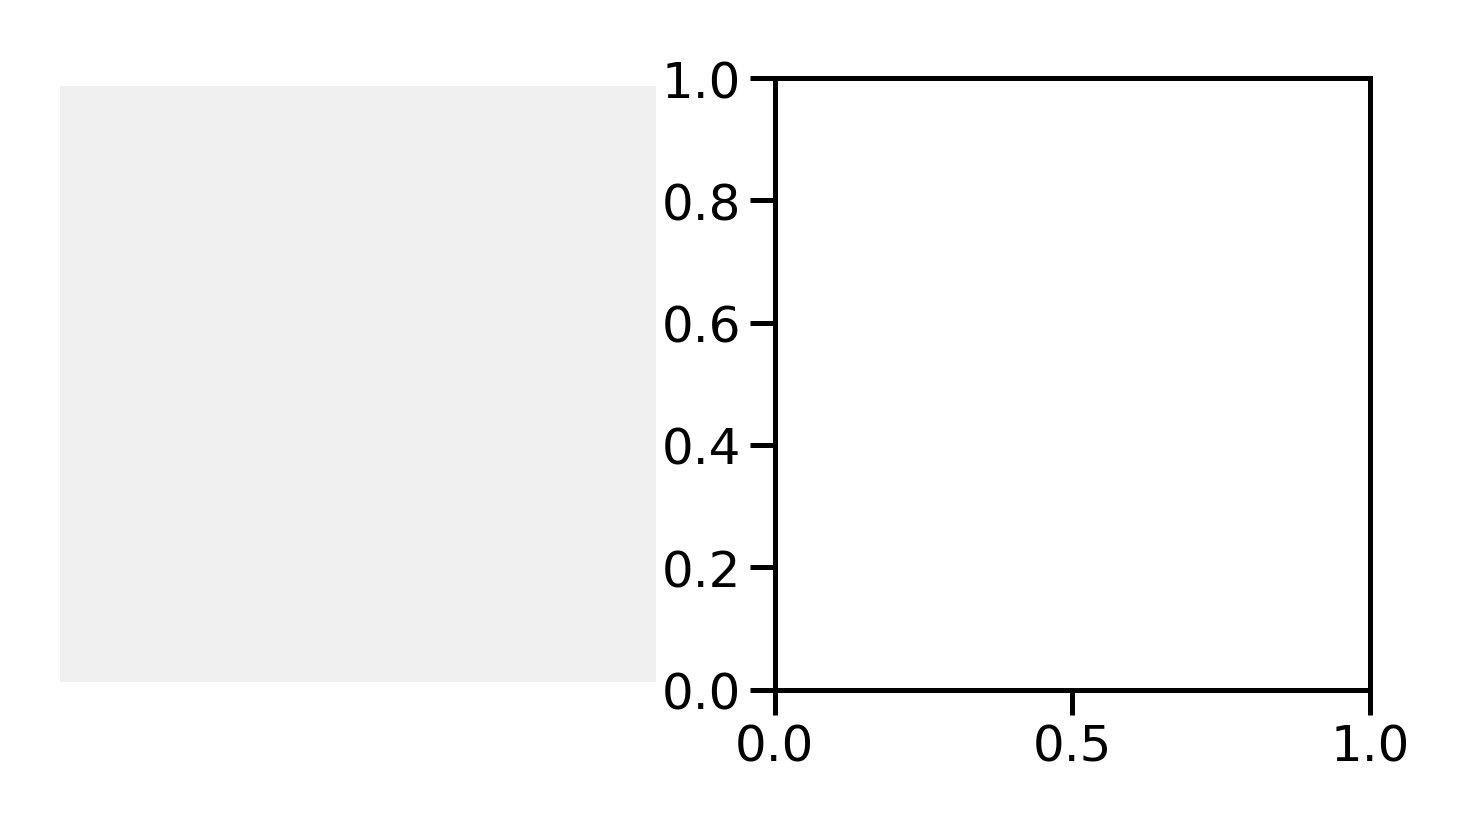

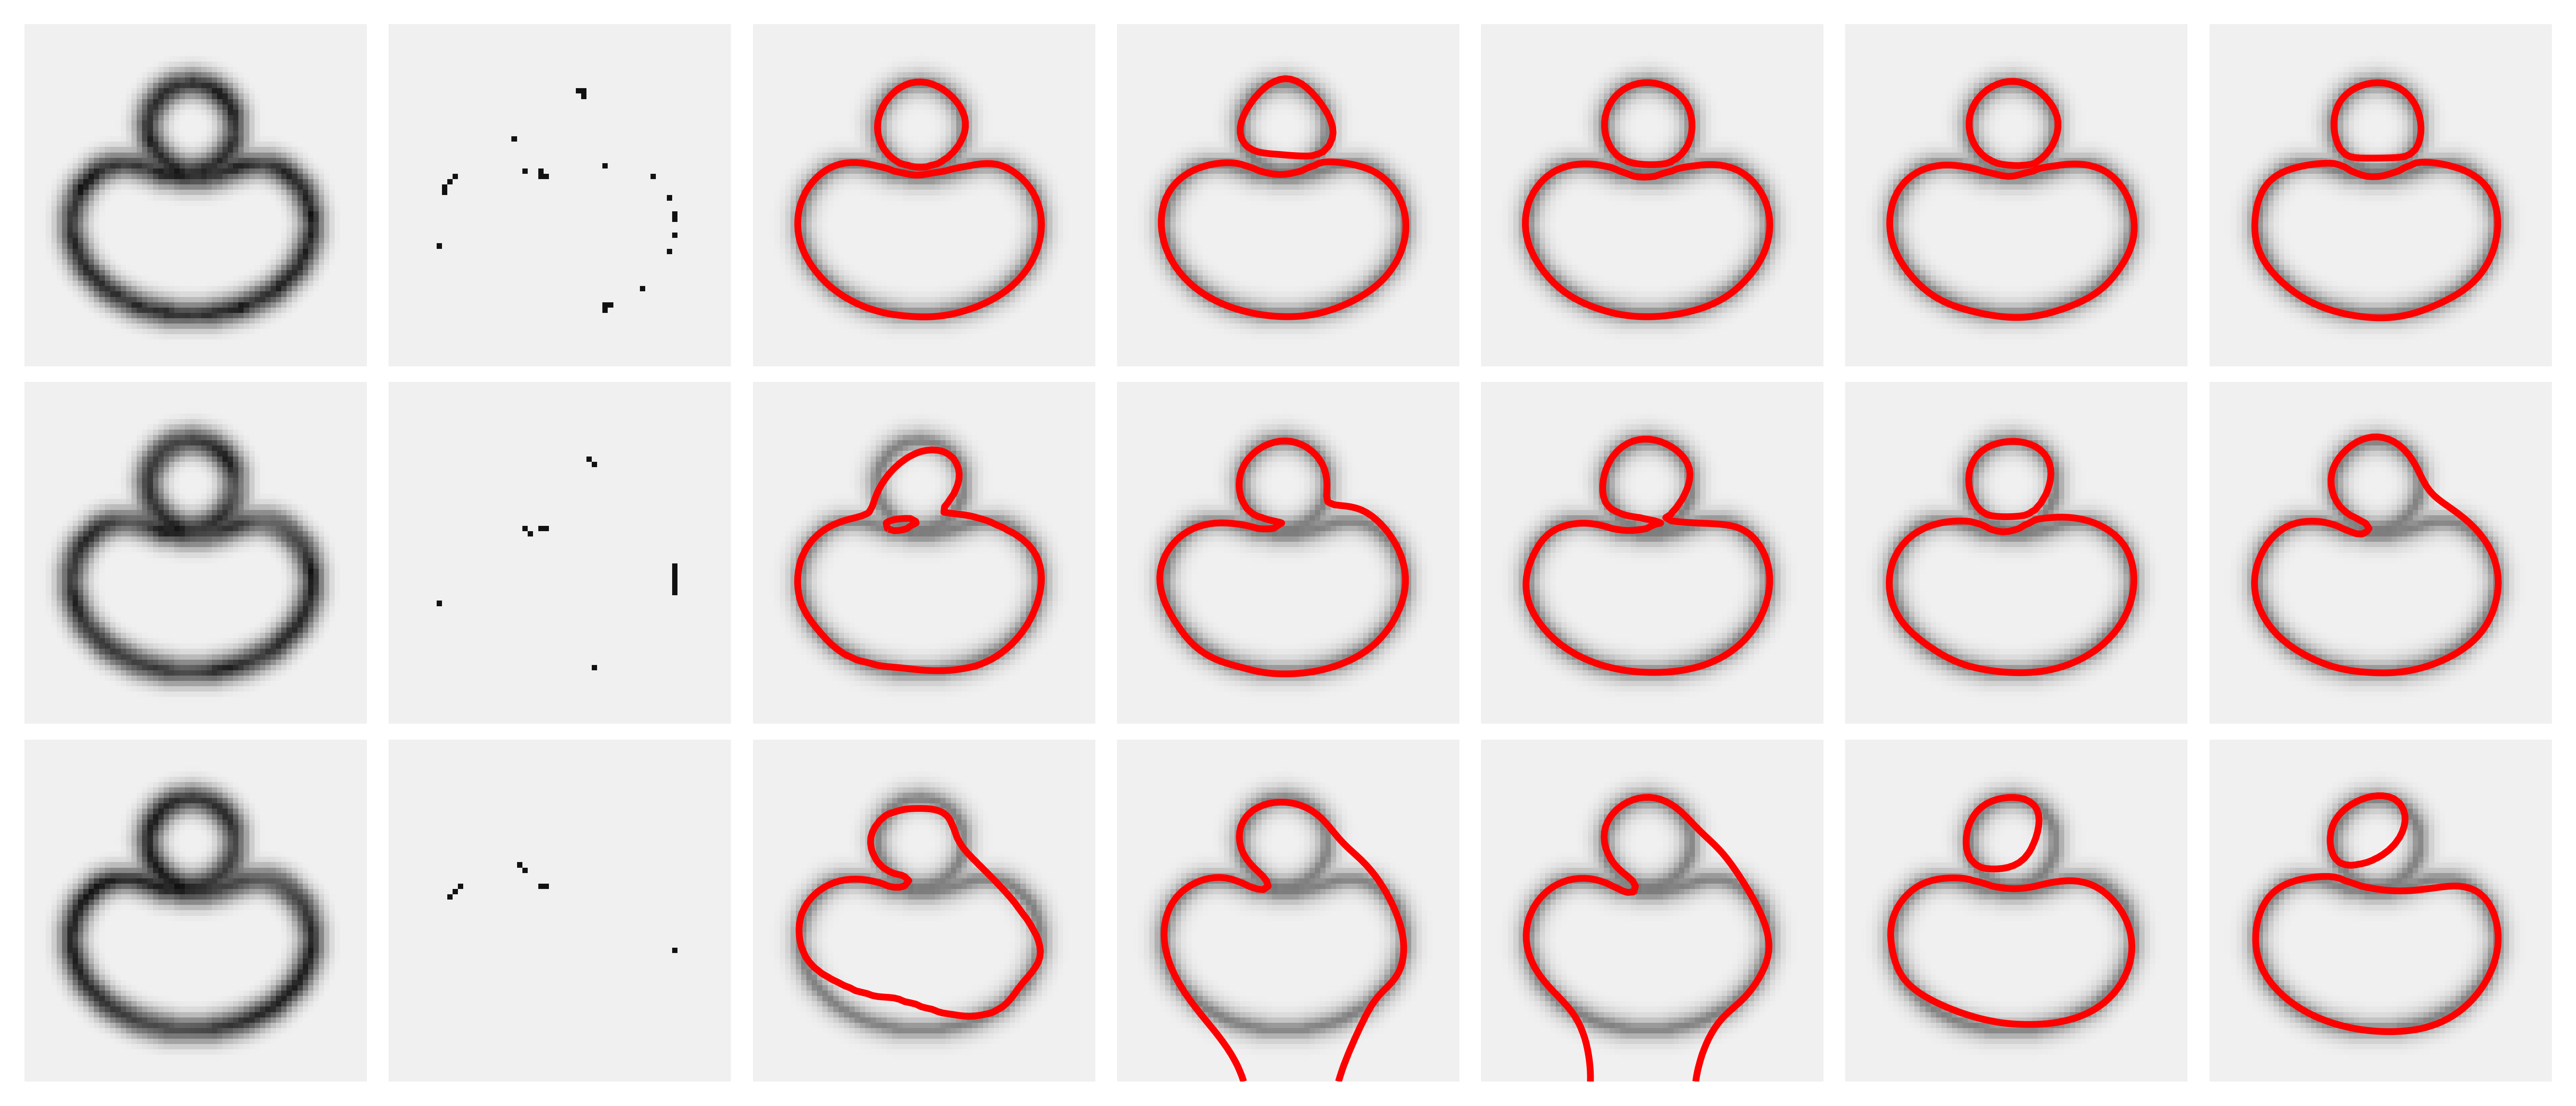

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile
import jax
import jax.numpy as jnp


GRID_SIZE = 64
lambda_1 = 1000000
lambda_2_list = [0, 10, 30, 50, 70]
hetero_scale_list = [1, 5, 10]
# hetero_scale_list = [1, 2, 3]
step = 10000
thre = 0.8
shape = "multi"
data_type = "data_0926"


# Load checkpoint data
checkpoint_data = {}
for lambda_2 in lambda_2_list:
    checkpoint_data[lambda_2] = {}
    for hetero_scale in hetero_scale_list:
        checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/h{hetero_scale}/lambda_{lambda_1}_{lambda_2}")
        checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        checkpoint_data[lambda_2][hetero_scale] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load input data
input_data = {}
for hetero_scale in hetero_scale_list:
    input_file = f"../data/synthetic/hetero/{shape}_h{hetero_scale}.mrc"
    # with mrcfile.open(input_file, permissive=True) as mrc:
        # volume = mrc.data
    # input_data[hetero_scale] = volume
    input_data[hetero_scale] = load_mrc_data(input_file, grid_size=GRID_SIZE)

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    n = len(lambda_2_list)       # lambda_2 columns
    m = len(hetero_scale_list)     # hetero_list rows
    n_col = n+2
    fig = plt.figure(figsize=(1.5*n_col, 1.5*m))
    
    for i, hetero_scale in enumerate(hetero_scale_list):      # rows
    
        ax = fig.add_subplot(m, n_col, i * n_col + 1)  # First column in row
        plot_single_slice(input_data[hetero_scale], ax=ax, axis="z", slice_index=GRID_SIZE//2, thre=None, show_title=False)
    
        ax = fig.add_subplot(m, n_col, i * n_col + 2)  # Second column in row
        plot_single_slice(input_data[hetero_scale], ax=ax, axis="z", slice_index=GRID_SIZE//2, thre=0.8, show_title=False) 
    
        for j, lambda_2 in enumerate(lambda_2_list):      # columns
            ax = fig.add_subplot(m, n_col, i * n_col + j + 3)
            data = checkpoint_data[lambda_2][hetero_scale]
    
            if data is not None:
                visualize_cryoET_with_contours(
                    ax, step, data, cryoET_data,
                    grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", no_label=True
                )
            else:
                ax.axis("off")
    
    
    
    plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/hetero_{shape}.png", dpi=600, bbox_inches="tight")
    plt.show()


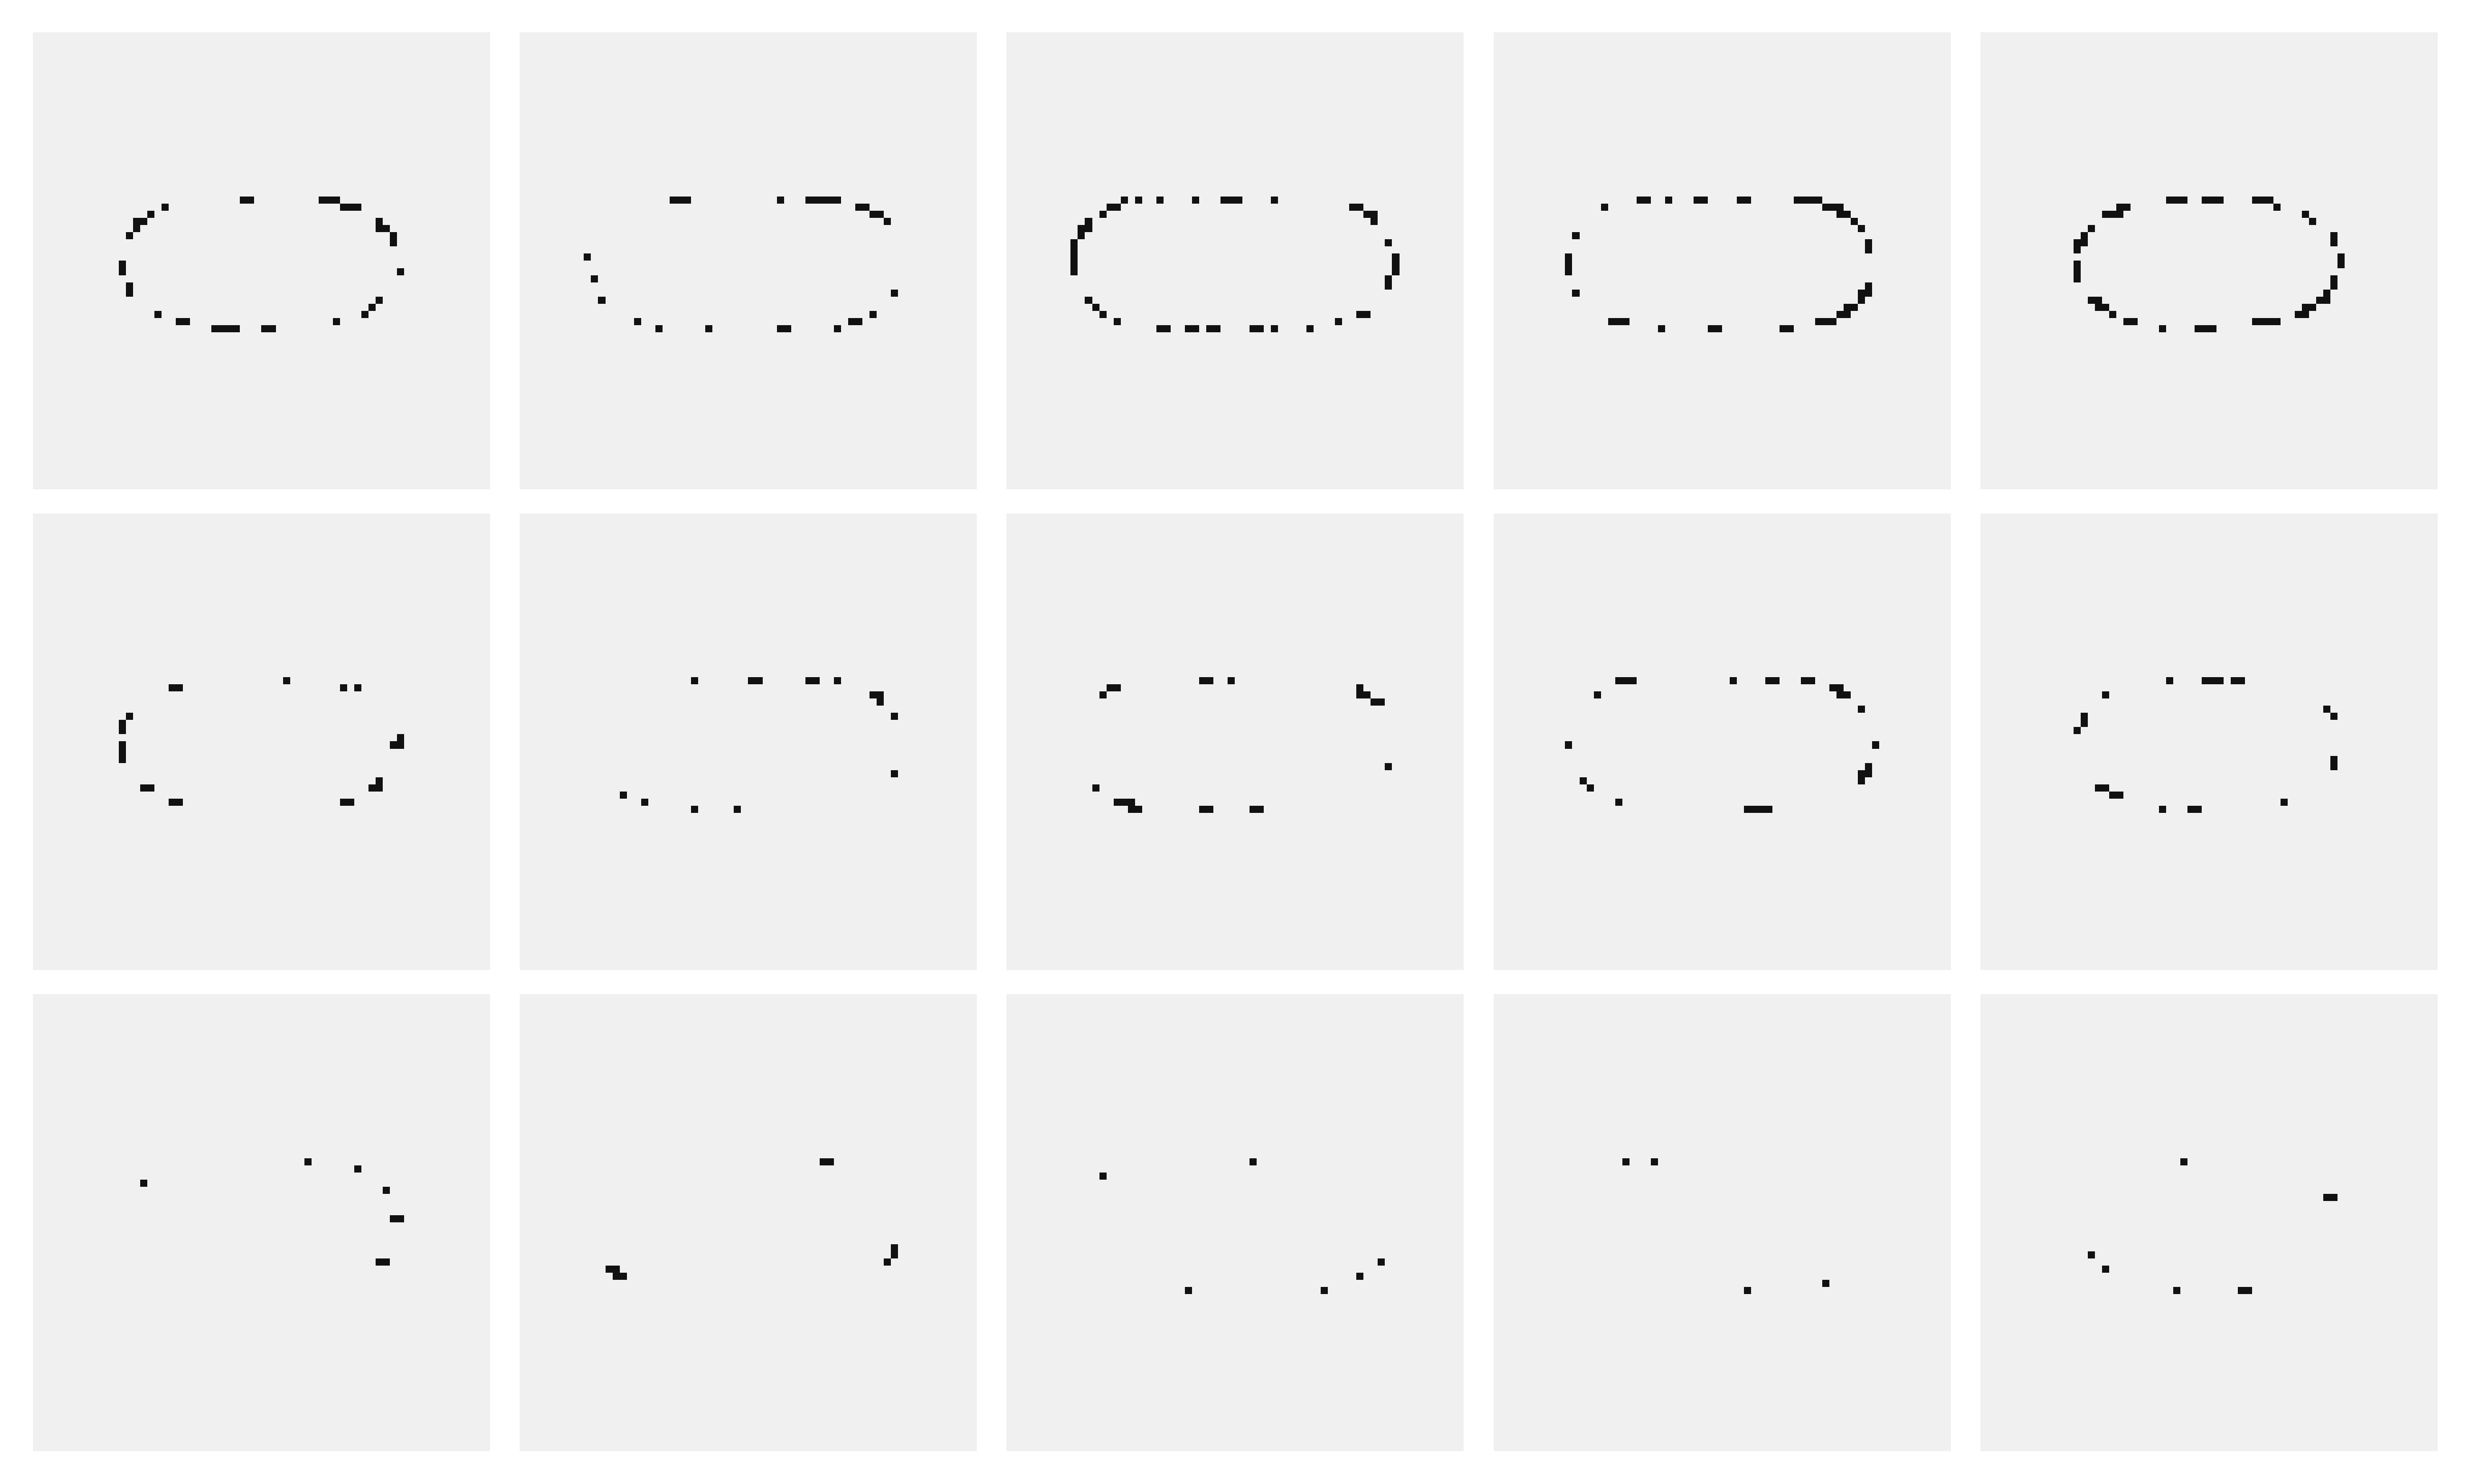

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile
import jax
import jax.numpy as jnp


GRID_SIZE = 64
noise_type = "missing"
# noise_type = "flip_noise"
# noise_type = "additive"
# noise_list = [1, 5, 10]
noise_list = [0.75, 0.85, 0.95]
# noise_list = [1, 2, 3]
# noise_list = [0.1, 0.15, 0.2]
# noise_list = [0.15, 0.2, 0.25]
# noise_list = [0.15, 0.2, 0.23]
thre = 0.8
# thre = None
shape = "biconcave"
slice_list = [20, 26, 32, 38, 44]
# slice_list = [40, 52, 64, 76, 88]

# Load input data
input_data = {}
for noise in noise_list:
    noise_str = str(noise).replace('.', '')
    if noise_type == "flip_noise":
        input_file = f"../data/synthetic/{noise_type}/{shape}_f{noise_str}.mrc"
    elif noise_type == "hetero":
        input_file = f"../data/synthetic/{noise_type}/{shape}_h{noise_str}.mrc"
    elif noise_type == "additive":
        input_file = f"../data/synthetic/{noise_type}/{shape}_f{noise_str}.mrc"
    elif noise_type == "missing":
        input_file = f"../data/synthetic/{noise_type}/{shape}_m{noise_str}.mrc"        

    # with mrcfile.open(input_file, permissive=True) as mrc:
    #     volume = mrc.data
    # volume = (volume - np.min(volume)) / (np.max(volume) - np.min(volume))
    
    volume = load_mrc_data(input_file, grid_size=GRID_SIZE)
    input_data[noise] = volume


plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    n = len(slice_list)    # slice columns
    m = len(noise_list)    # noise rows

    fig = plt.figure(figsize=(1.5*n, 1.5*m))
    
    for i, noise in enumerate(noise_list): # rows
        data = input_data[noise]
        
        for j, slice_id in enumerate(slice_list): # columns
            ax = fig.add_subplot(m, n, i * n + j + 1)
    
            if data is not None:
                plot_single_slice(data, ax=ax, axis="z", slice_index=slice_id, thre=thre, show_title=False) 
            else:
                ax.axis("off")
    
        
    plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/input_{noise_type}_{shape}.png", dpi=600, bbox_inches="tight")
    plt.show()


Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)


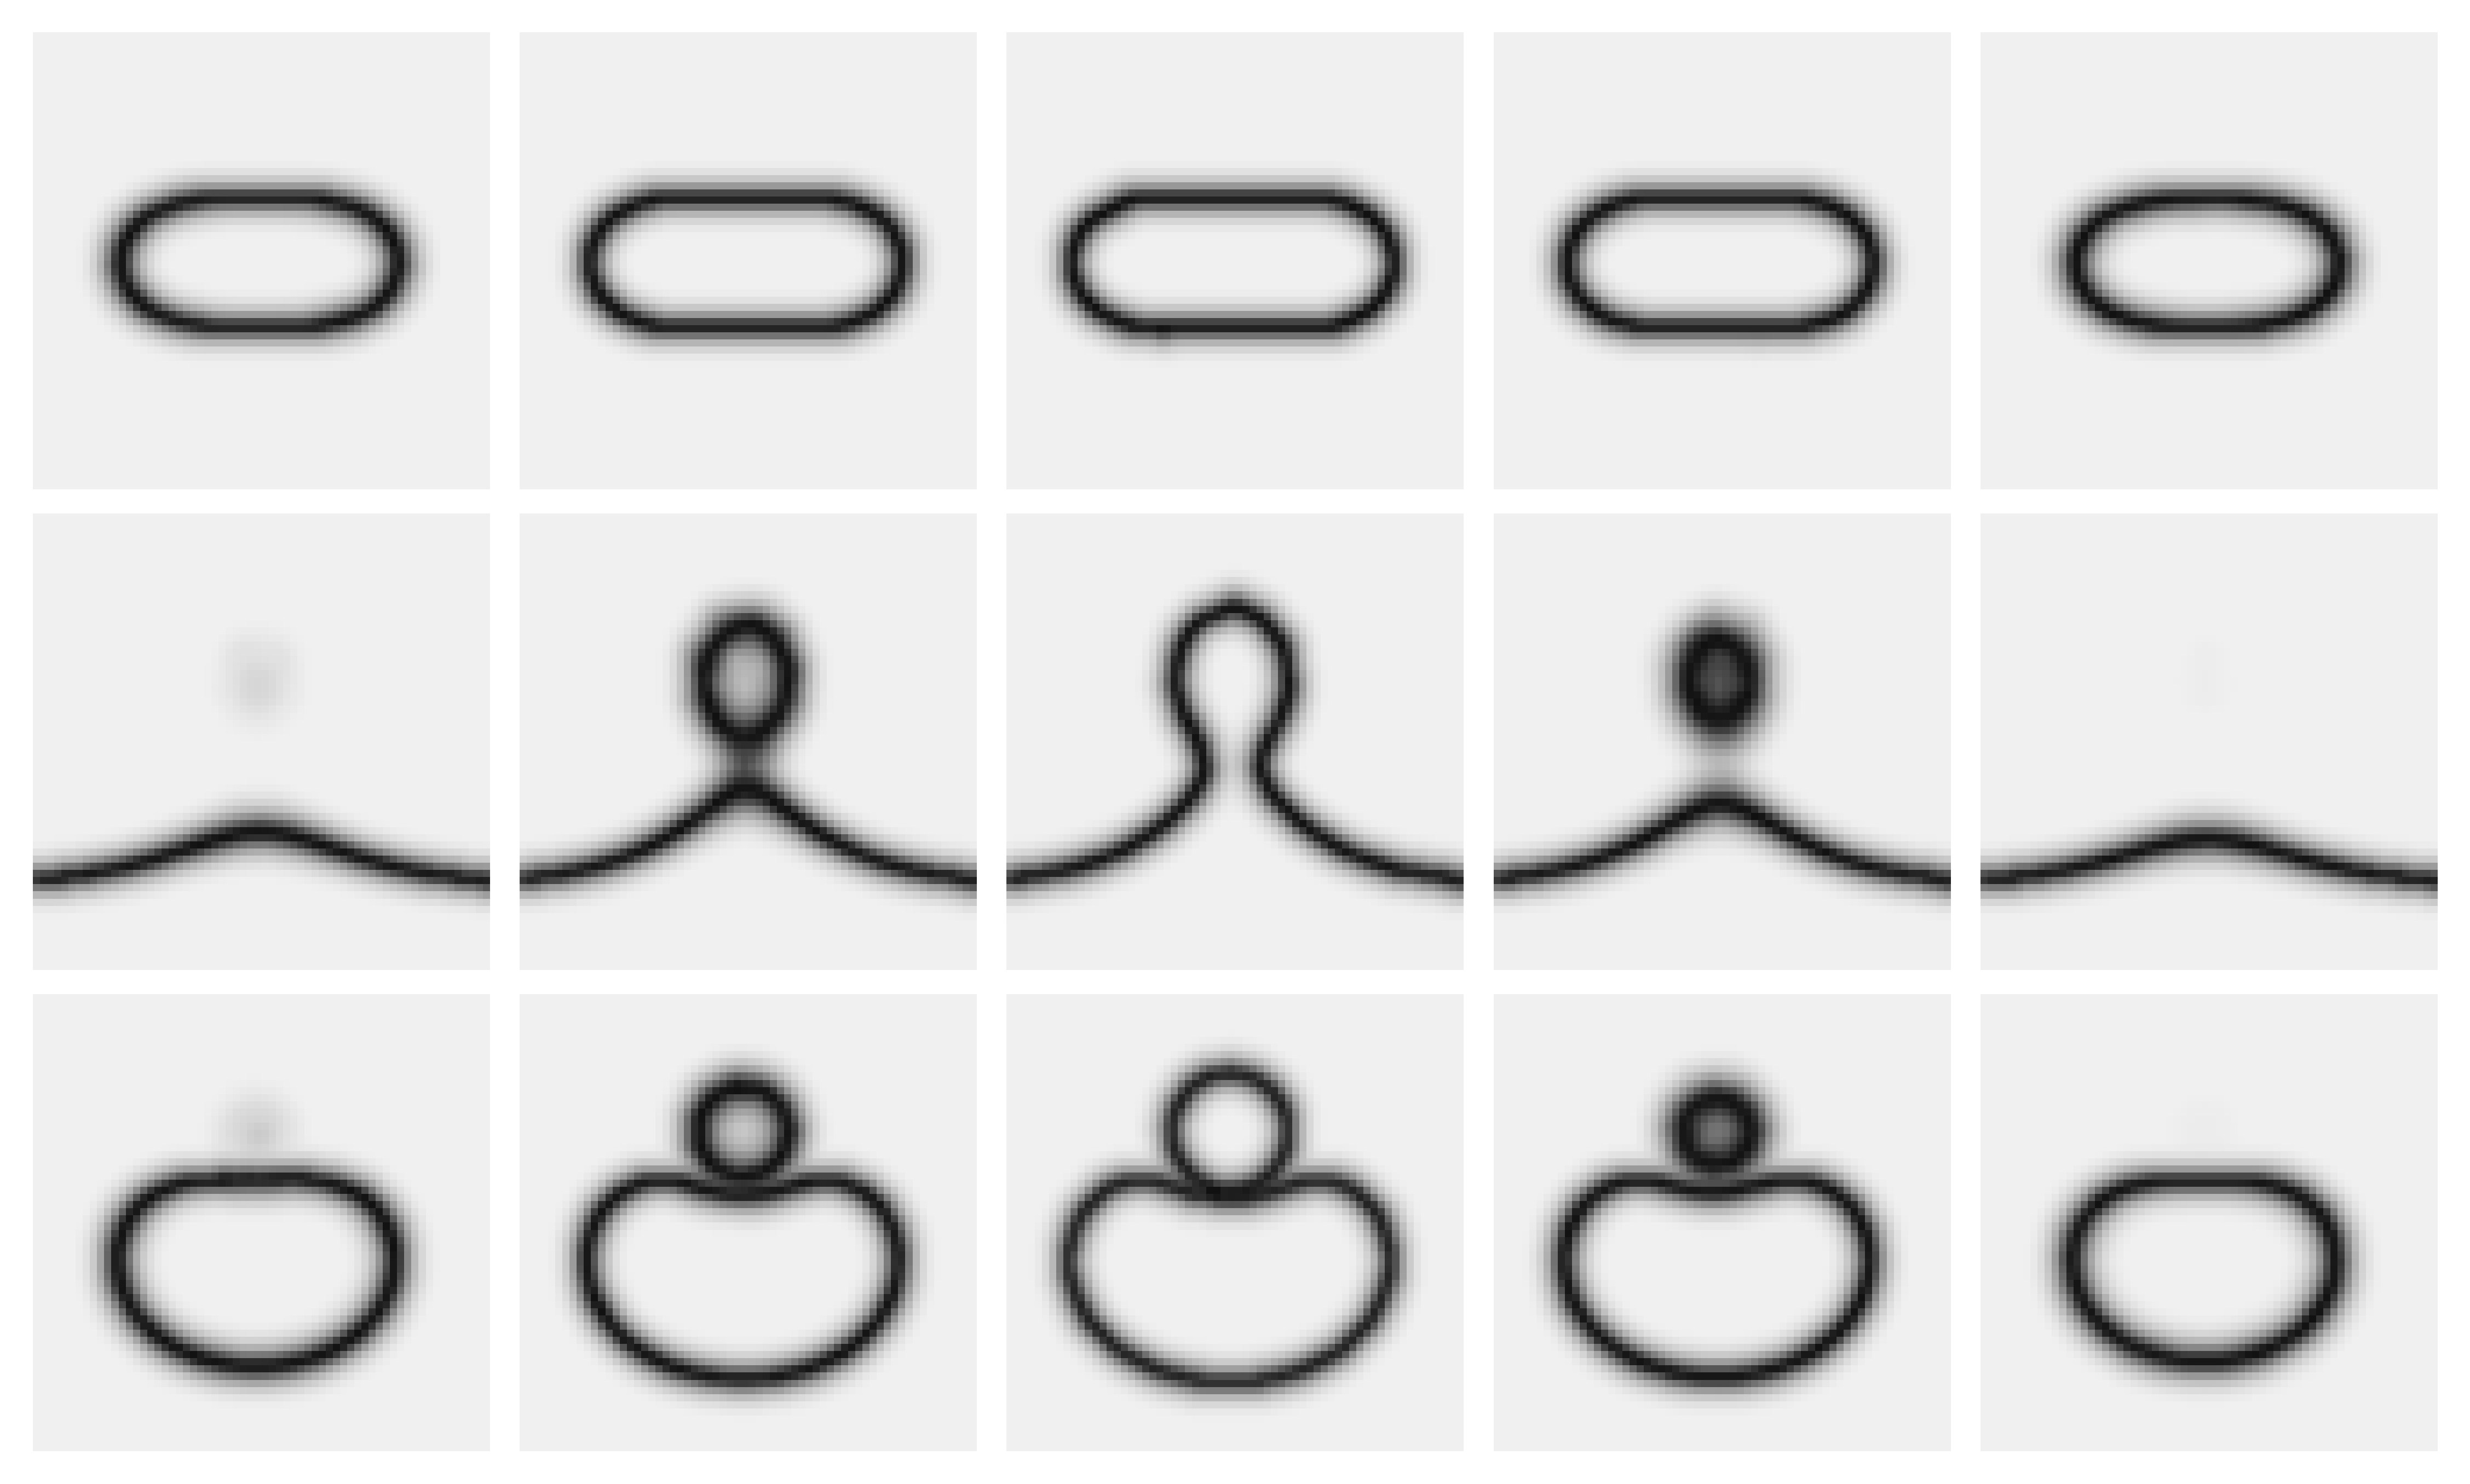

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile
import jax
import jax.numpy as jnp


GRID_SIZE = 64
thre = None
shape_list = ["biconcave", "bud_04", "multi"]
slice_list = [20, 26, 32, 38, 44]

for flip_ratio in [0.05]:
    for missing_ratio in [0.6]:

        flip_str = str(flip_ratio).replace('.', '')
        missing_str = str(missing_ratio).replace('.', '')
        
        # Load input data
        input_data = {}
        for shape in shape_list:
            # input_file = f"../data/synthetic/combine/{shape}_a{flip_str}_m{missing_str}.mrc"
            input_file = f"../data/synthetic/{shape}.mrc"
            if os.path.exists(input_file):
                volume = load_mrc_data(input_file, grid_size=GRID_SIZE)
                input_data[shape] = volume
        
        plt.style.reload_library()
        with plt.style.context(["base", "transparent"]):
        
            n = len(slice_list)    # slice columns
            m = len(shape_list)    # shape rows
        
            fig = plt.figure(figsize=(1.5*n, 1.5*m))
            
            for i, shape in enumerate(shape_list): # rows
                # data = input_data[shape]
                data = input_data.get(shape, None)
                
                for j, slice_id in enumerate(slice_list): # columns
                    ax = fig.add_subplot(m, n, i * n + j + 1)
            
                    if data is not None:
                        plot_single_slice(data, ax=ax, axis="z", slice_index=slice_id, thre=thre, show_title=False) 
                    else:
                        ax.axis("off")
            
                
            plt.tight_layout()
            # plt.savefig(f"../outputs/figs/sync/noise/input_a{flip_str}_m{missing_str}.png", dpi=600, bbox_inches="tight")
            plt.savefig(f"../outputs/figs/sync/input_raw_clean.png", dpi=600, bbox_inches="tight")
            plt.show()

Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)


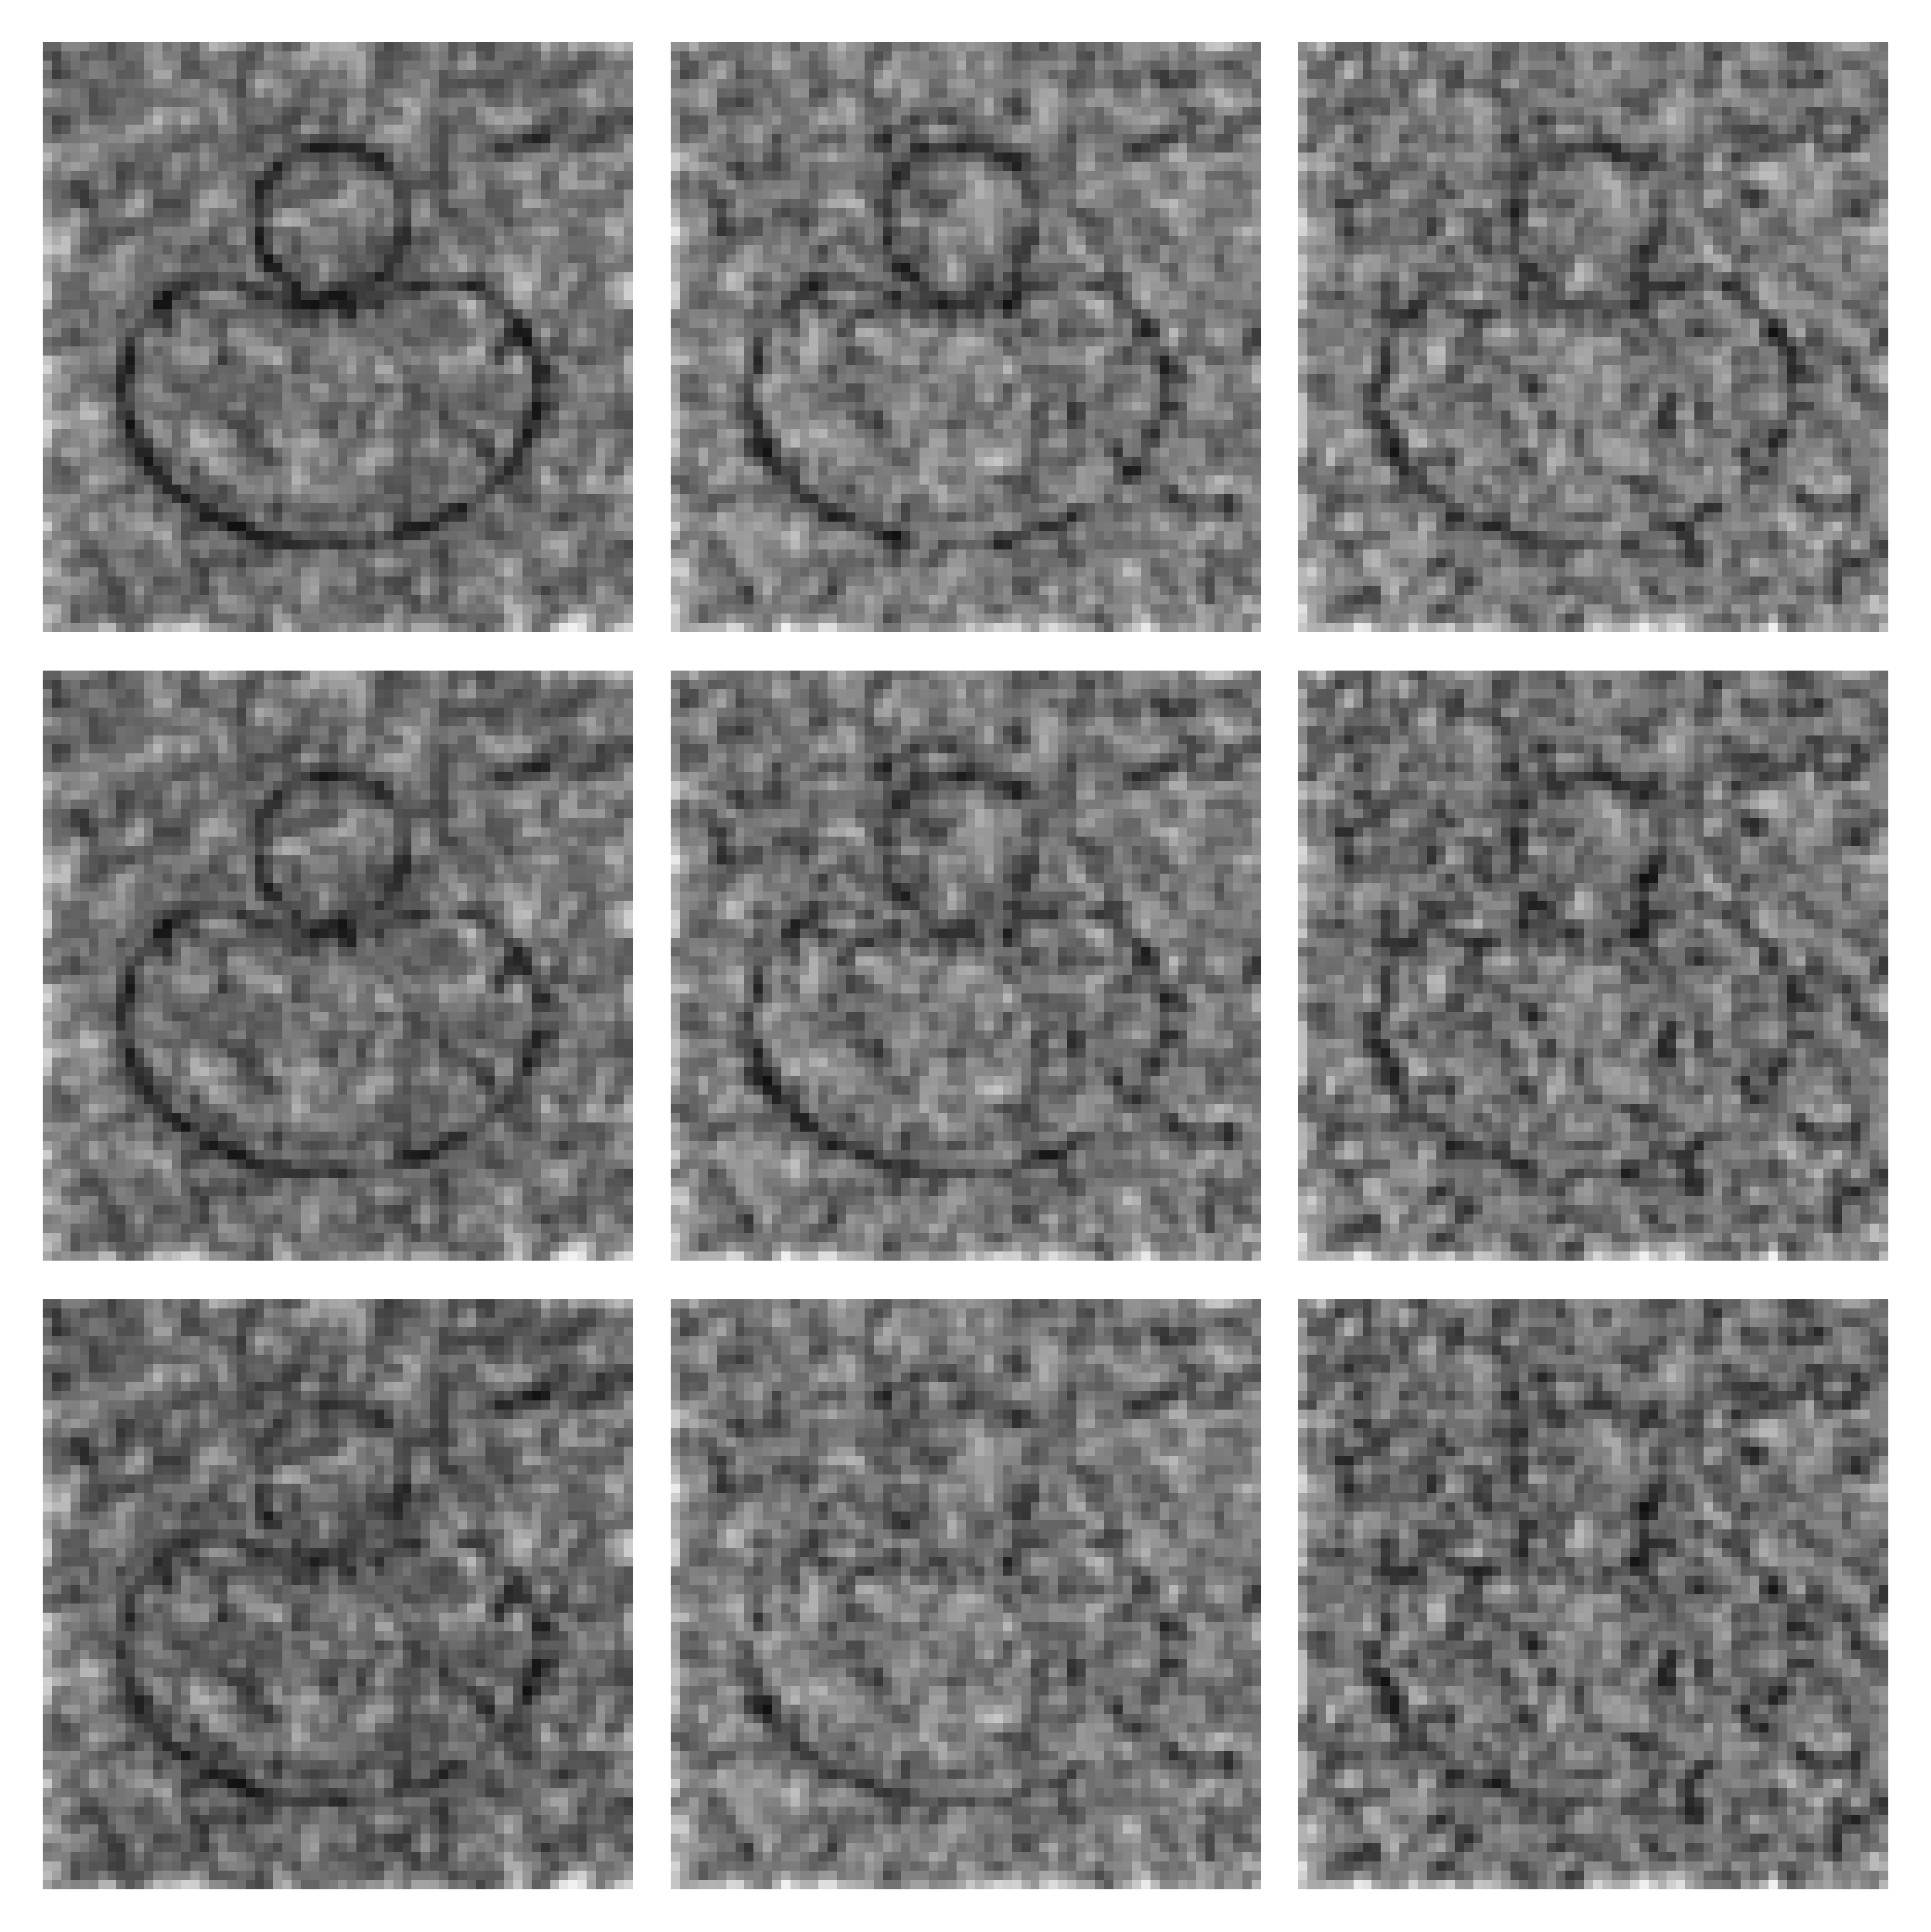

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile
import jax
import jax.numpy as jnp


GRID_SIZE = 64
thre = None
shape = "multi"
flip_list = [0.05, 0.1, 0.15]
missing_list = [0.6, 0.7, 0.8]


input_data = {}
for flip_ratio in flip_list:
    flip_str = str(flip_ratio).replace('.', '')
    input_data[flip_ratio] = {}

    for missing_ratio in missing_list:
        missing_str = str(missing_ratio).replace('.', '')

        input_file = f"../data/synthetic/combine/{shape}_a{flip_str}_m{missing_str}.mrc"

        if os.path.exists(input_file):
            volume = load_mrc_data(input_file, grid_size=GRID_SIZE)
            input_data[flip_ratio][missing_ratio] = volume


plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    n = len(flip_list)       # columns
    m = len(missing_list)    # rows

    fig = plt.figure(figsize=(1.5*n, 1.5*m))
    
    for j, flip_ratio in enumerate(flip_list): # columns
        for i, missing_ratio in enumerate(missing_list): # rows

            ax = fig.add_subplot(m, n, i * n + j + 1)
            data = input_data[flip_ratio][missing_ratio]
    
            if data is not None:
                plot_single_slice(data, ax=ax, axis="z", slice_index=GRID_SIZE//2, thre=thre, show_title=False) 
            else:
                ax.axis("off")
    
    plt.tight_layout()
    plt.savefig(f"../outputs/figs/sync/noise/input_raw_{shape}.png", dpi=600, bbox_inches="tight")
    plt.show()

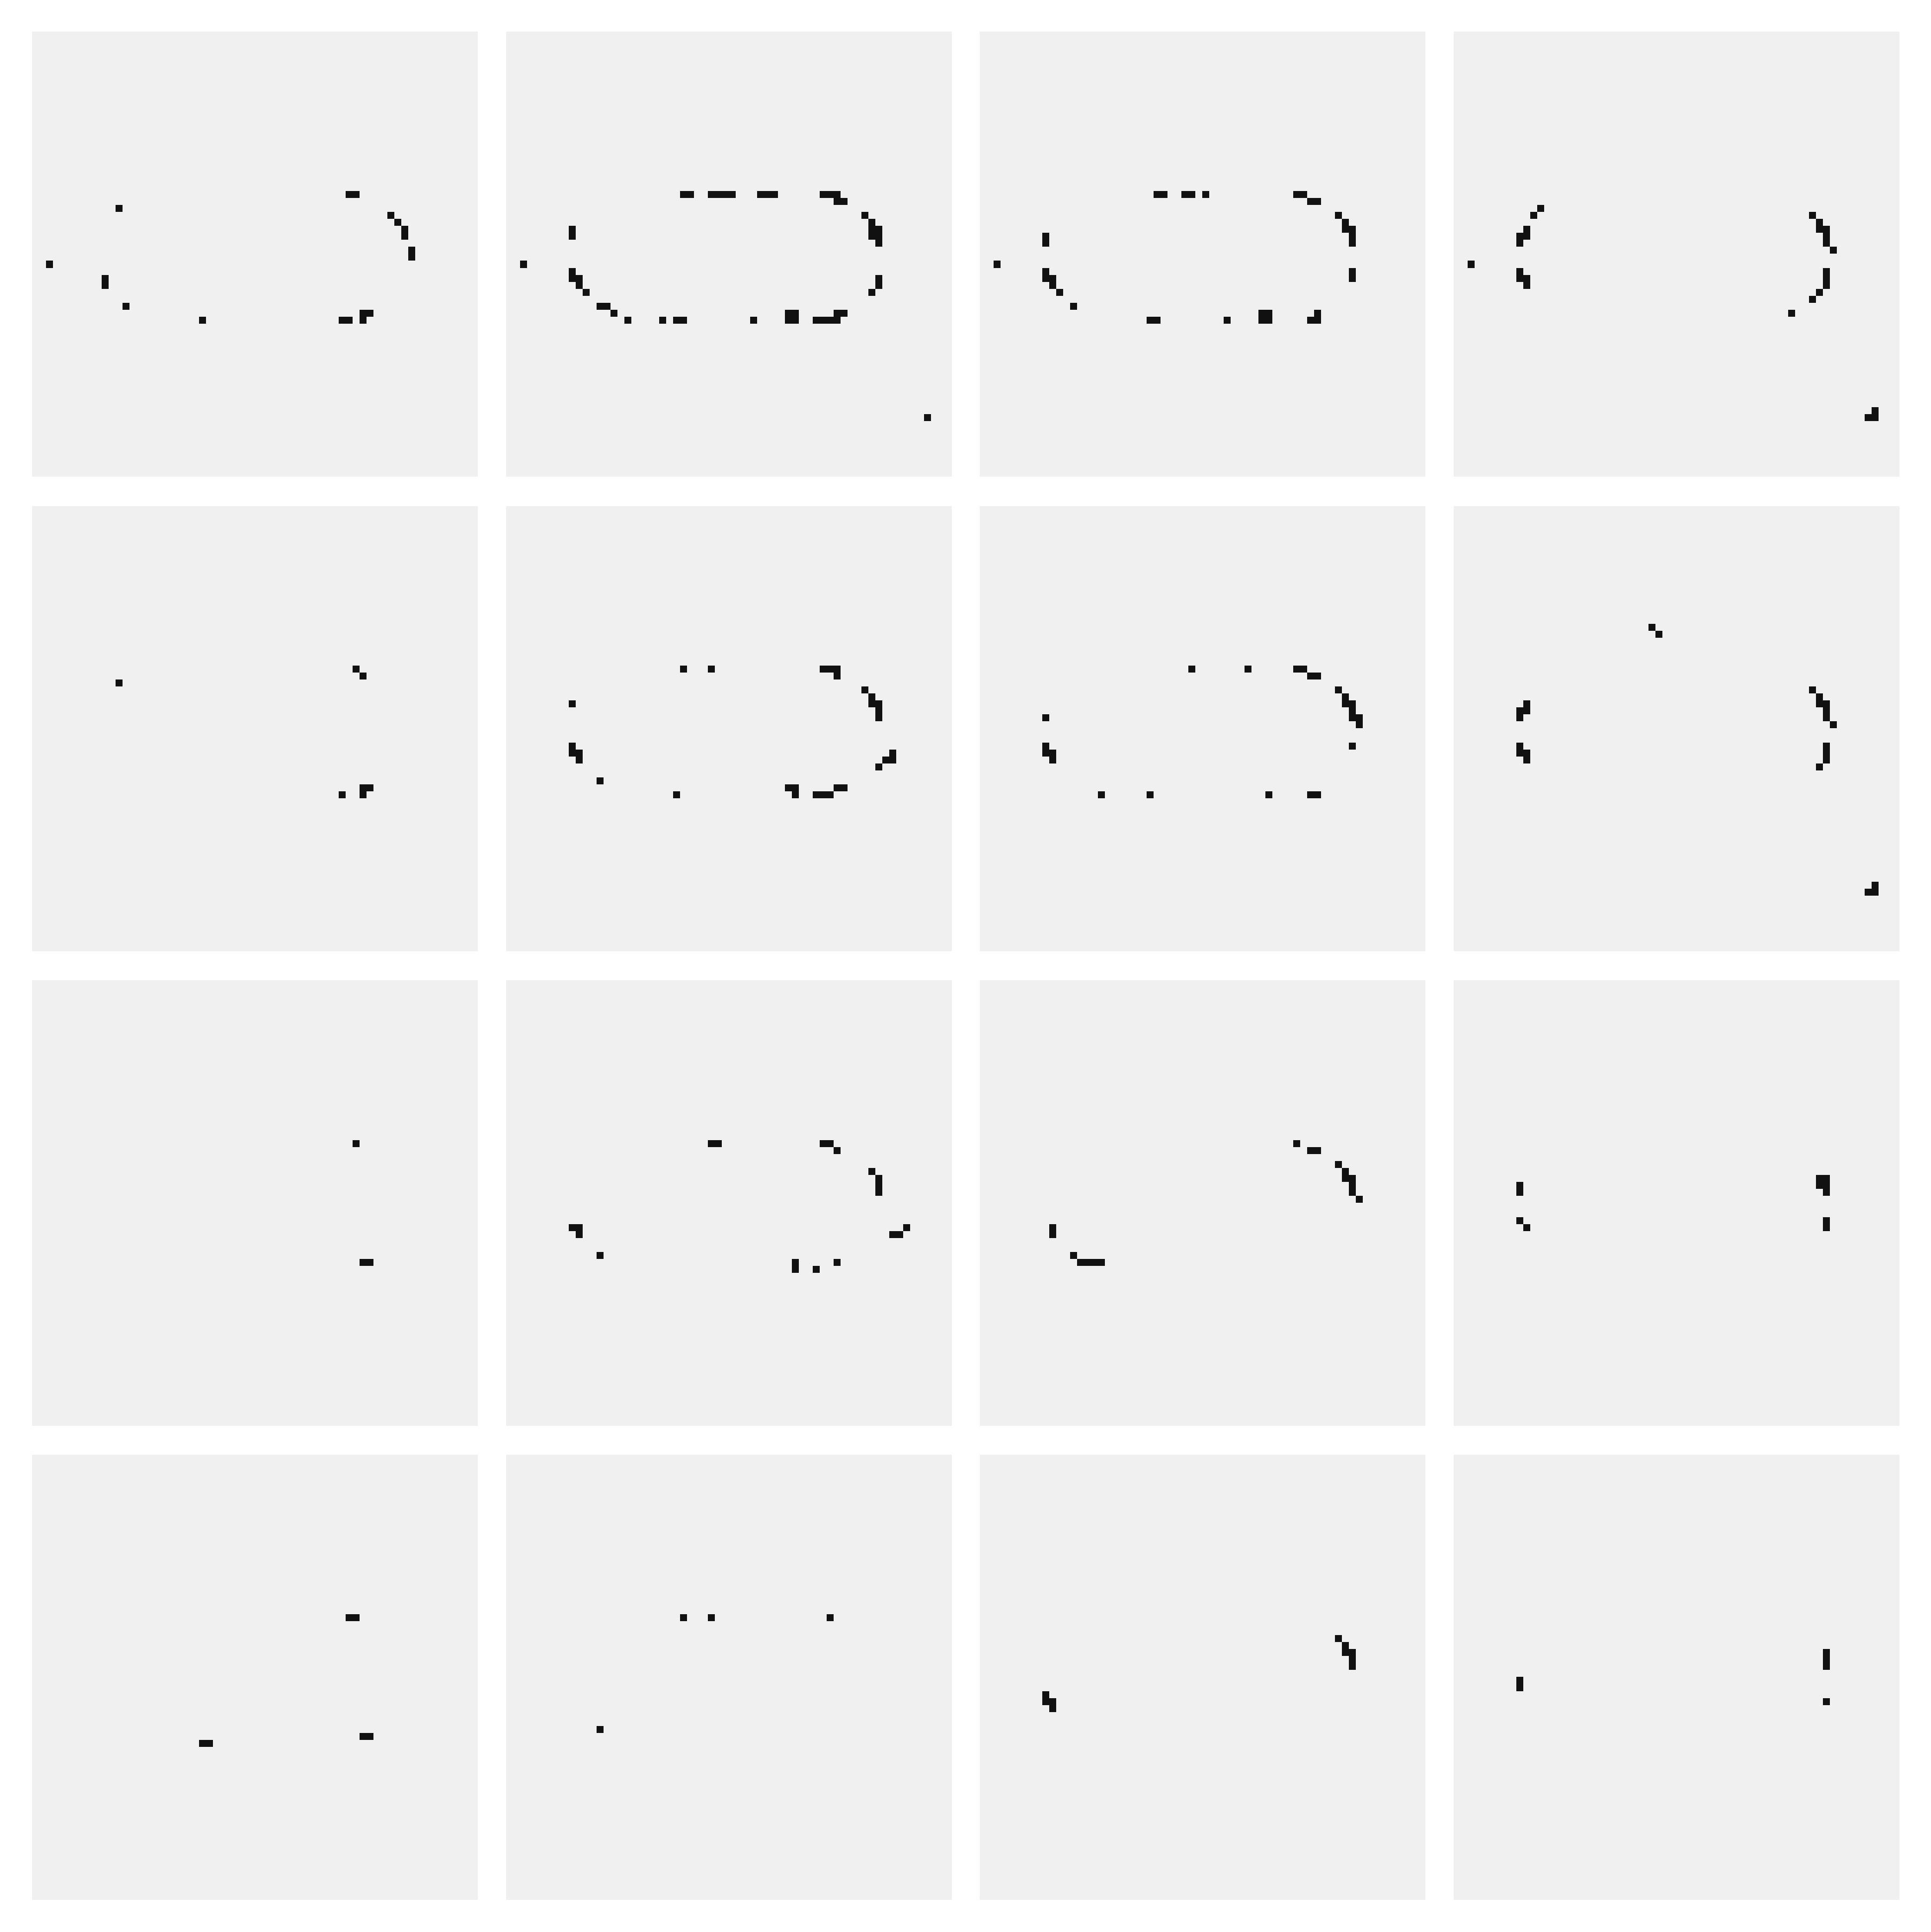

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile
import jax
import jax.numpy as jnp


GRID_SIZE = 64
thre = 0.8
shape = "biconcave"
flip_ratio = 0.1
axis_angle_list = [90, 60, 30, 0]
tilt_max_list = [80, 70, 60, 50]


input_data = {}
for axis_angle in axis_angle_list:
    input_data[axis_angle] = {}
    for tilt_max in tilt_max_list:
        input_file = f"../data/synthetic/wedge/{shape}_a{str(flip_ratio).replace('.', '')}_w{axis_angle:02d}_t{tilt_max:02d}.mrc"
        if os.path.exists(input_file):
            volume = load_mrc_data(input_file, grid_size=GRID_SIZE)
            input_data[axis_angle][tilt_max] = volume


plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    m = len(tilt_max_list)   
    n = len(axis_angle_list) 

    fig = plt.figure(figsize=(1.5*n, 1.5*m))
    
    for i, tilt_max in enumerate(tilt_max_list): # columns
        for j, axis_angle in enumerate(axis_angle_list): # rows

            ax = fig.add_subplot(m, n, i * n + j + 1)
            data = input_data[axis_angle][tilt_max]
    
            if data is not None:
                plot_single_slice(data, ax=ax, axis="y", slice_index=GRID_SIZE//2, thre=thre, show_title=False) 
            else:
                ax.axis("off")
    
    plt.tight_layout()
    plt.savefig(f"../outputs/figs/sync/wedge/input_thre_{shape}.png", dpi=600, bbox_inches="tight")
    plt.show()

Resizing MRC data from (128, 128, 128) to (64, 64, 64)


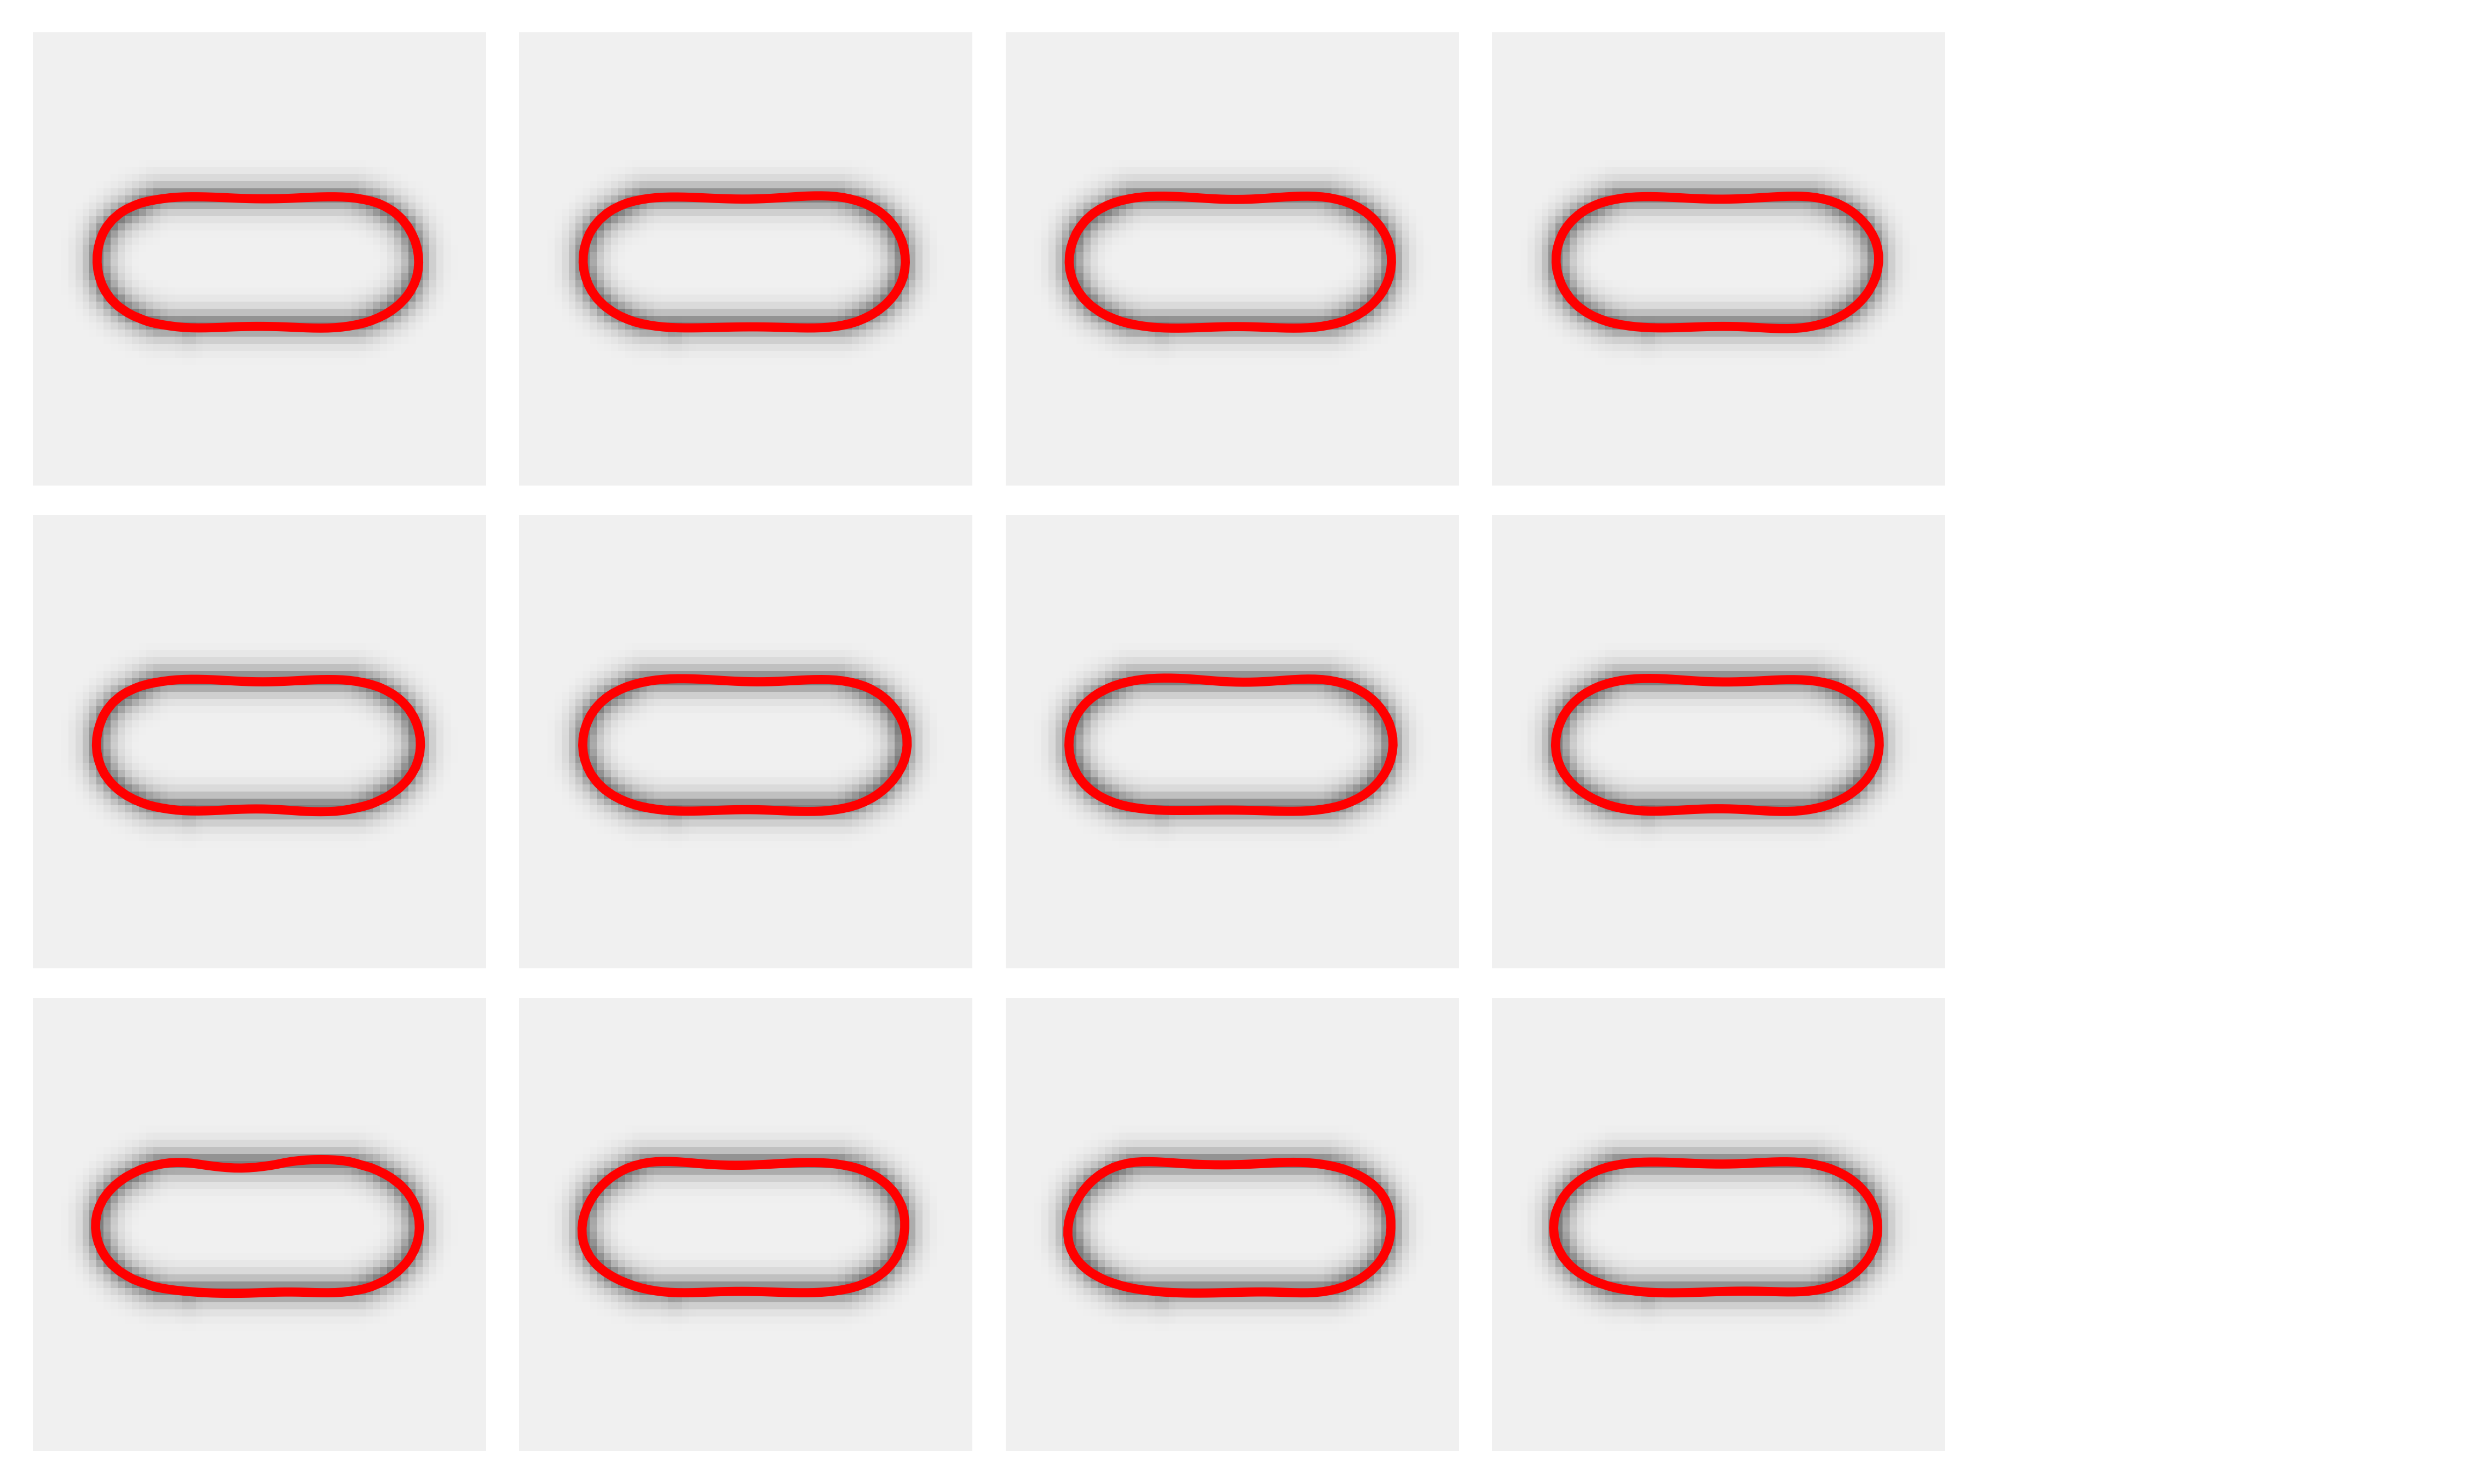

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours
import mrcfile
import jax
import jax.numpy as jnp


GRID_SIZE = 64
lambda_1 = 1000000
# lambda_2_list = [0, 10, 30, 50, 70]
lambda_2_list = [0, 10, 100, 1000, 10000, 100000]
# noise_list = [0.15, 0.2, 0.25]
# noise_list = [1,2,3]
noise_list = [0.75, 0.85, 0.95]
step = 10000
thre = 0.8
shape = "biconcave"
data_type = "data_1115"
# noise_type = "additive"
noise_type = "missing"

# Load checkpoint data
checkpoint_data = {}
for lambda_2 in lambda_2_list:
    checkpoint_data[lambda_2] = {}
    for noise in noise_list:
        noise_str = str(noise).replace('.', '')
        # checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/a{noise_str}/lambda_{lambda_1}_{lambda_2}")
        # checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/h{noise_str}/lambda_{lambda_1}_{lambda_2}")
        checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/m{noise_str}/lambda_{lambda_1}_{lambda_2}")
        checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        checkpoint_data[lambda_2][noise] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    n = len(lambda_2_list)     # lambda_2 columns
    m = len(noise_list)        # noise_list rows
    fig = plt.figure(figsize=(1.5*n, 1.5*m))
    
    for i, noise in enumerate(noise_list):      # rows
    
        for j, lambda_2 in enumerate(lambda_2_list):      # columns
            ax = fig.add_subplot(m, n, i * n + j + 1)
            data = checkpoint_data[lambda_2][noise]
    
            if data is not None:
                visualize_cryoET_with_contours(
                    ax, step, data, cryoET_data,
                    grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis="z", no_label=True
                )
            else:
                ax.axis("off")
    
    
        plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/noise_{noise_type}_{shape}.png", dpi=600, bbox_inches="tight")
    plt.show()

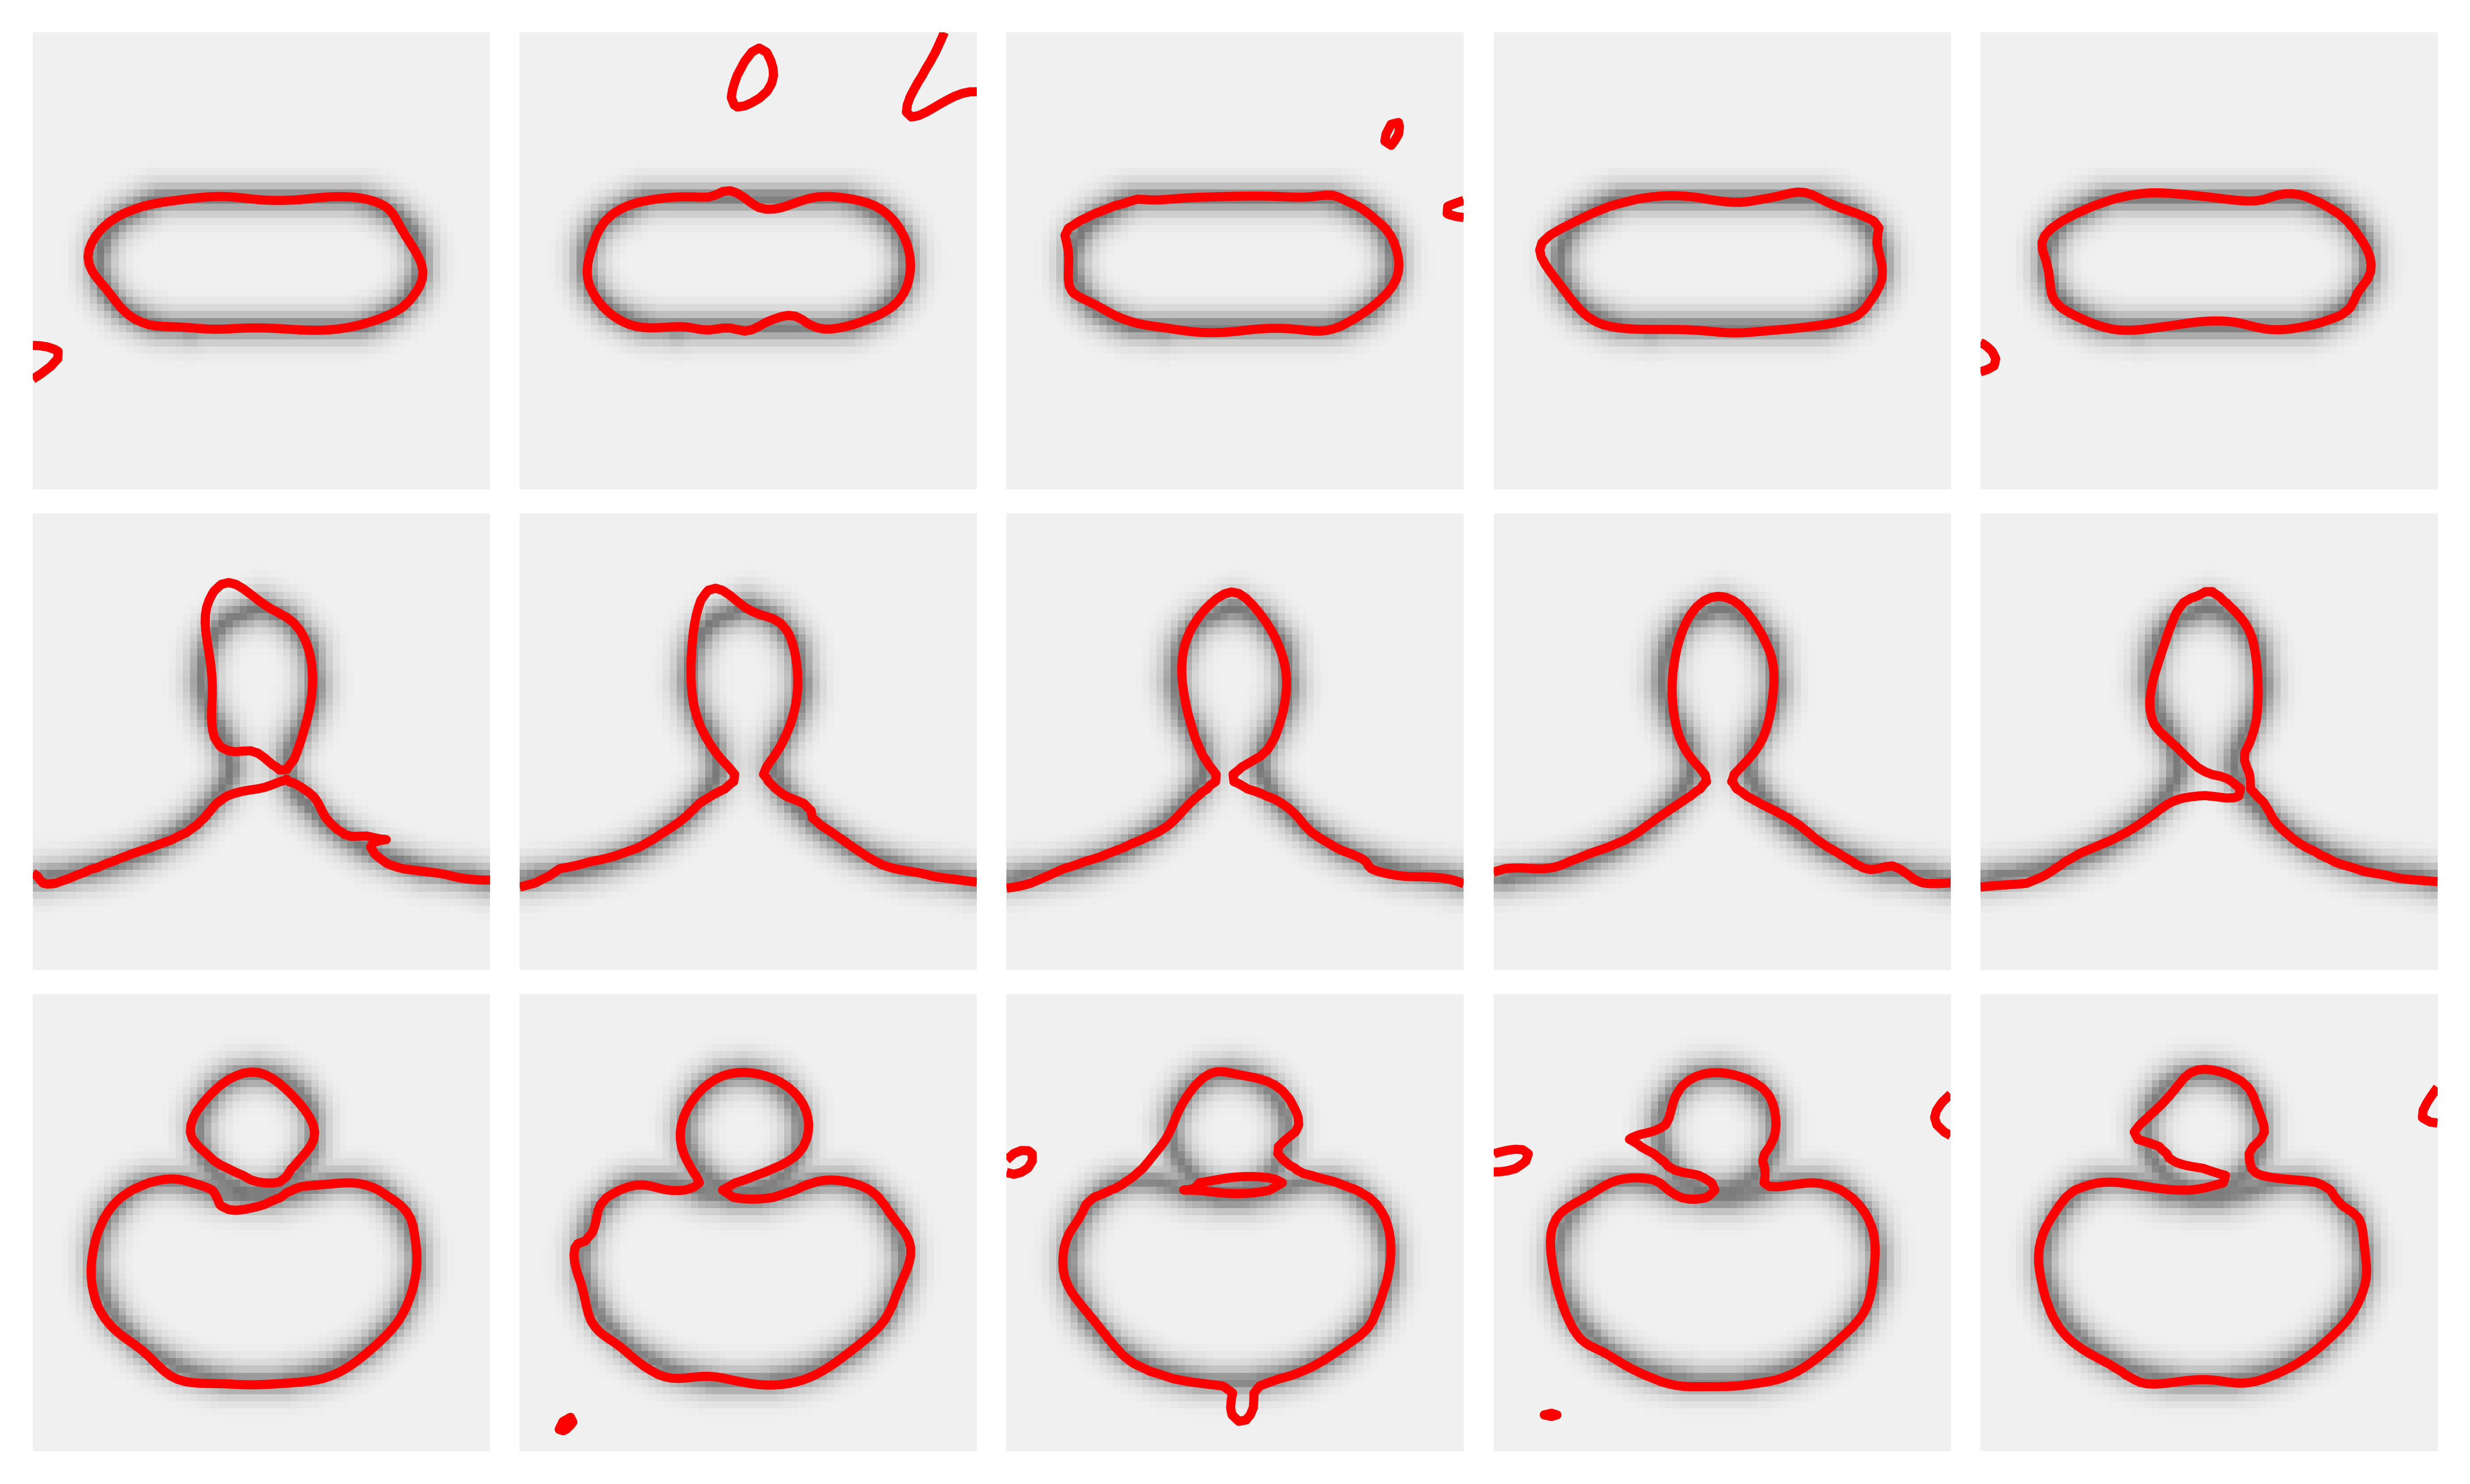

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours
import mrcfile
import jax
import jax.numpy as jnp

GRID_SIZE = 64
lambda_1 = 1000000
# lambda_2_list = [0, 10, 50, 100]
# flip_list = [0.1, 0.15, 0.2]
# missing_list = [0.6, 0.7, 0.8]
lambda_2_list = [0, 10, 30, 50, 70]
flip_list = [0.15]
missing_list = [0.7]
step = 10000
shape_list = ["biconcave", "bud_04", "multi"]
# data_type = "data_1115"
data_type = "data_1203"

for flip_ratio in flip_list:
    for missing_ratio in missing_list:
        
        flip_str = str(flip_ratio).replace('.', '')
        missing_str = str(missing_ratio).replace('.', '')
        
        # Load checkpoint data
        checkpoint_data = {}
        for shape in shape_list:
            checkpoint_data[shape] = {}
            for lambda_2 in lambda_2_list:
                checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/combine/a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lambda_2}")
                checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
                checkpoint_data[shape][lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
        
        # Load CryoET data
        input_mrc = {}
        for shape in shape_list:
            mrc_file_path = f"../data/synthetic/{shape}.mrc"
            cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
            input_mrc[shape] = cryoET_data
        
        
        plt.style.reload_library()
        with plt.style.context(["base", "transparent"]):
        
            n = len(lambda_2_list)     # lambda_2 columns
            m = len(shape_list)        # shape rows
            fig = plt.figure(figsize=(1.5*n, 1.5*m))
            
            for i, shape in enumerate(shape_list):      # rows
            
                for j, lambda_2 in enumerate(lambda_2_list):      # columns
                    ax = fig.add_subplot(m, n, i * n + j + 1)
                    data = checkpoint_data[shape][lambda_2]
            
                    if data is not None:
                        visualize_cryoET_with_contours(
                            ax, step, data, input_mrc[shape],
                            grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis="z", no_label=True
                        )
                    else:
                        ax.axis("off")
            
            
            plt.tight_layout()
            # plt.savefig(f"../outputs/figs/sync/noise/pinn_a{flip_str}_m{missing_str}.png", dpi=600, bbox_inches="tight")
            # plt.savefig(f"../outputs/figs/sync/noise/pinn_tension_a{flip_str}_m{missing_str}.png", dpi=600, bbox_inches="tight")            
            plt.show()

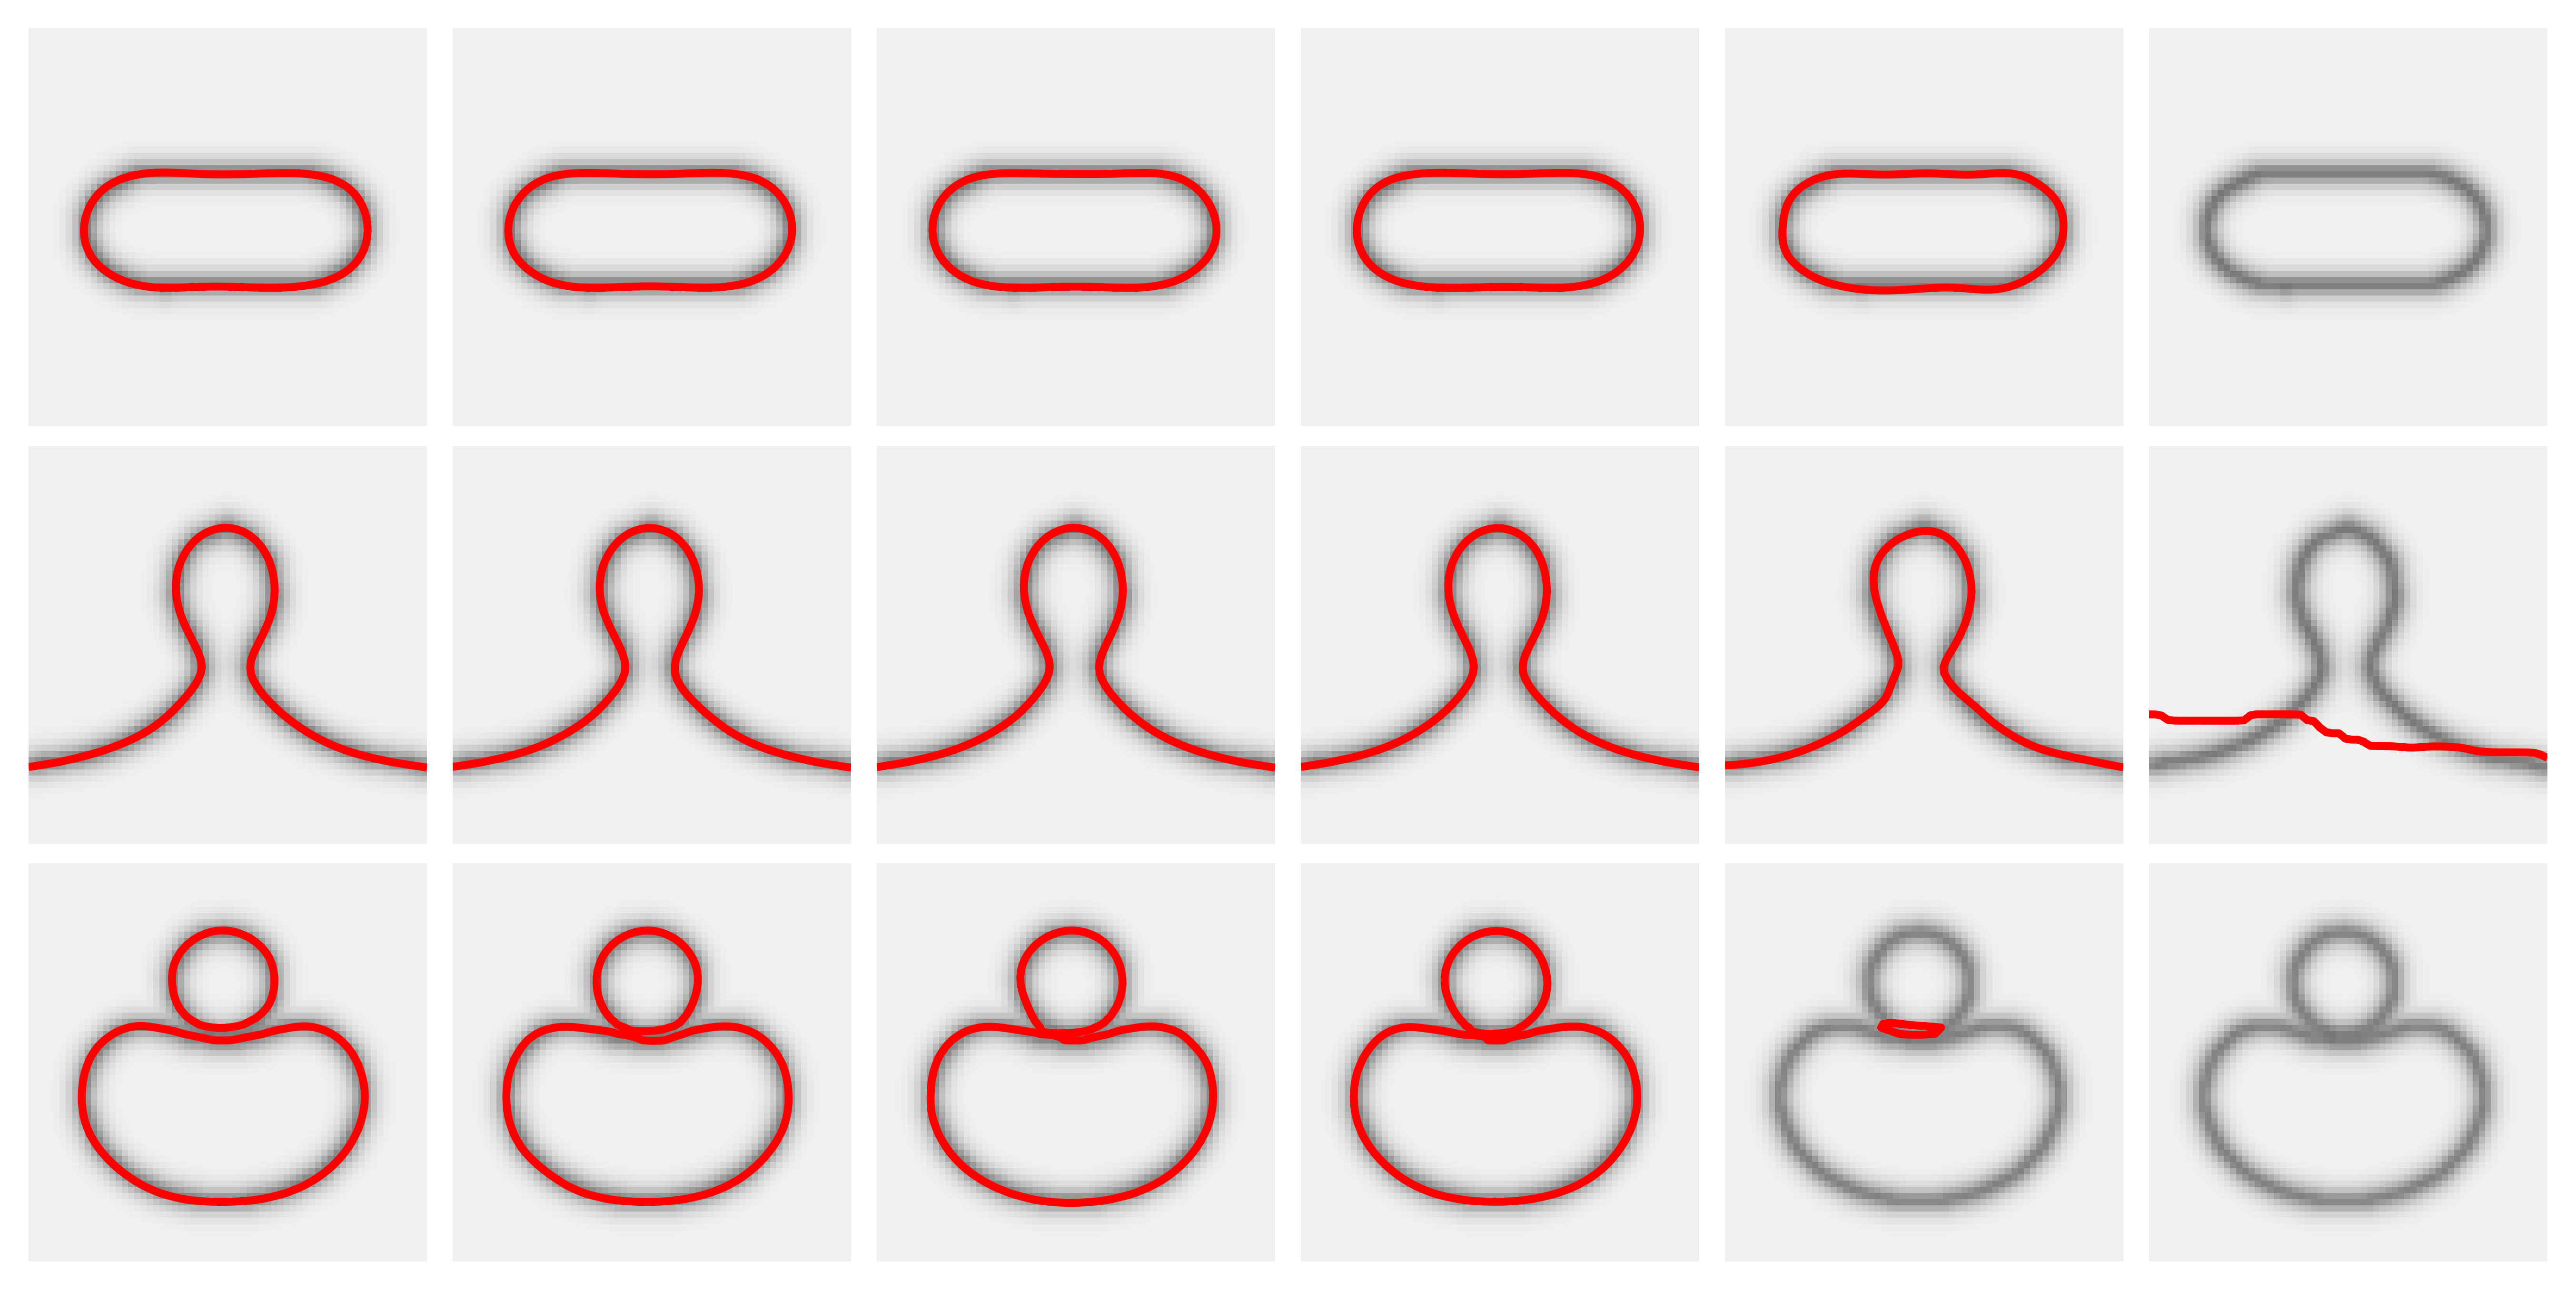

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours
import mrcfile
import jax
import jax.numpy as jnp

GRID_SIZE = 64
lambda_1 = 1000000
lambda_2_list = [1, 10, 100, 1000, 10000, 100000]
step = 10000
shape_list = ["biconcave", "bud_04", "multi"]
# data_type = "data_1115"
data_type = "data_1203"


        
flip_str = str(flip_ratio).replace('.', '')
missing_str = str(missing_ratio).replace('.', '')

# Load checkpoint data
checkpoint_data = {}
for shape in shape_list:
    checkpoint_data[shape] = {}
    if shape == "biconcave":
        sdf = "sphere"
    elif shape == "bud_04":
        sdf = "plane"
    elif shape == "multi":
        sdf = "multi"
    for lambda_2 in lambda_2_list:
        checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/clean/{sdf}/lambda_{lambda_1}_{lambda_2}")
        checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        checkpoint_data[shape][lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
input_mrc = {}
for shape in shape_list:
    mrc_file_path = f"../data/synthetic/{shape}.mrc"
    cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
    input_mrc[shape] = cryoET_data


plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    n = len(lambda_2_list)     # lambda_2 columns
    m = len(shape_list)        # shape rows
    fig = plt.figure(figsize=(1.5*n, 1.5*m))
    
    for i, shape in enumerate(shape_list):      # rows
    
        for j, lambda_2 in enumerate(lambda_2_list):      # columns
            ax = fig.add_subplot(m, n, i * n + j + 1)
            data = checkpoint_data[shape][lambda_2]
    
            if data is not None:
                visualize_cryoET_with_contours(
                    ax, step, data, input_mrc[shape],
                    grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis="z", no_label=True
                )
            else:
                ax.axis("off")
    
    
    plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/noise/pinn_a{flip_str}_m{missing_str}.png", dpi=600, bbox_inches="tight")
    # plt.savefig(f"../outputs/figs/sync/noise/pinn_tension_a{flip_str}_m{missing_str}.png", dpi=600, bbox_inches="tight")            
    plt.show()

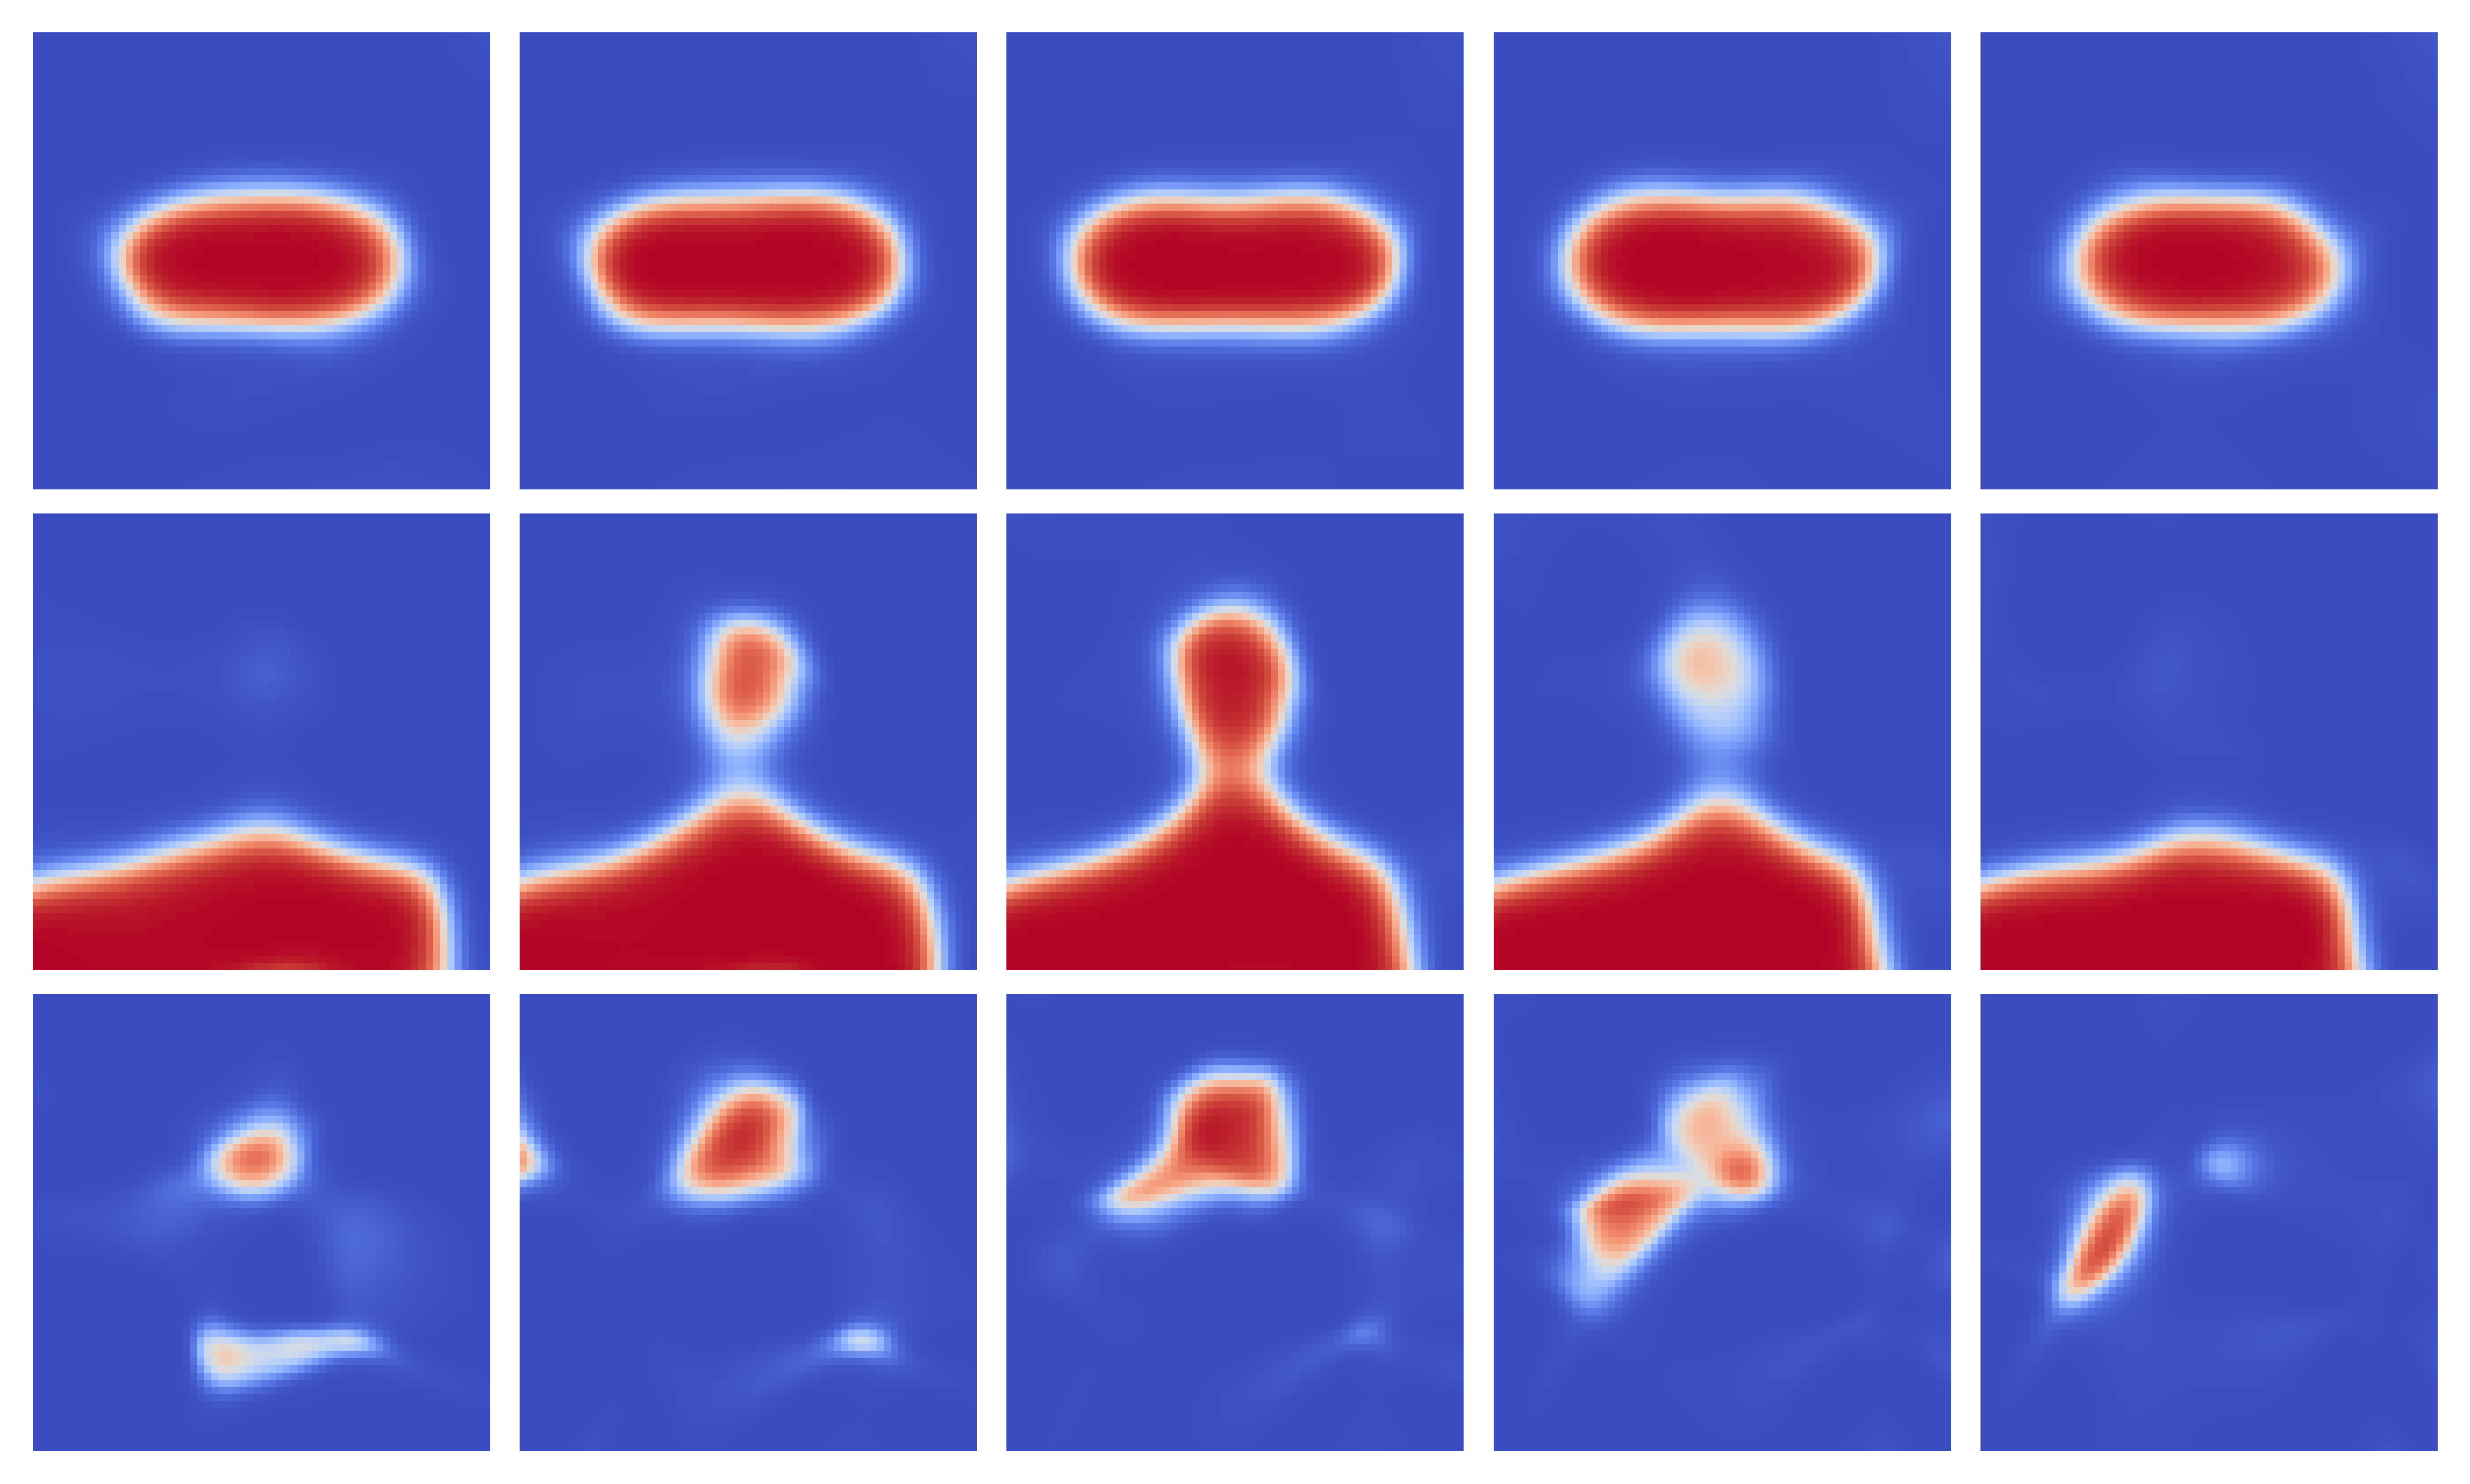

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours, visualize_physics_loss
import mrcfile
import jax
import jax.numpy as jnp

GRID_SIZE = 64
lambda_1 = 1000000
lambda_2 = 50
flip_list = [0.15]
missing_list = [0.7]
step = 10000
shape_list = ["biconcave", "bud_04", "multi"]
data_type = "data_1115"
slice_list = [20, 26, 32, 38, 44]
# plot_type = "contour"
plot_type = "phi"
epsilon = 0.05

for flip_ratio in flip_list:
    for missing_ratio in missing_list:
        
        flip_str = str(flip_ratio).replace('.', '')
        missing_str = str(missing_ratio).replace('.', '')
        
        # Load checkpoint data
        checkpoint_data = {}
        for shape in shape_list:
            checkpoint_data[shape] = {}
            if shape == "biconcave":
                checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/combine/a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lambda_2}")
            else:
                checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/combine-sphere/a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lambda_2}")
            # checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/combine/a{flip_str}_m{missing_str}/lambda_{lambda_1}_{lambda_2}")
            checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
            checkpoint_data[shape][lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
        
        # Load CryoET data
        input_mrc = {}
        for shape in shape_list:
            mrc_file_path = f"../data/synthetic/{shape}.mrc"
            cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
            input_mrc[shape] = cryoET_data
        
        
        plt.style.reload_library()
        with plt.style.context(["base", "transparent"]):
        
            n = len(slice_list)     # slice columns
            m = len(shape_list)        # shape rows
            fig = plt.figure(figsize=(1.5*n, 1.5*m))
            
            for i, shape in enumerate(shape_list):      # rows
            
                for j, slice_id in enumerate(slice_list):      # columns
                    ax = fig.add_subplot(m, n, i * n + j + 1)
                    data = checkpoint_data[shape][lambda_2]
            
                    if data is not None:
                        if plot_type == "contour":
                            visualize_cryoET_with_contours(
                                ax, step, data, input_mrc[shape],
                                grid_size=GRID_SIZE, slice_index=slice_id, axis="z", no_label=True
                            )
                        elif plot_type == "phi":
                            visualize_physics_loss(ax, epsilon=epsilon,
                               checkpoint=data, component="phi",
                               grid_size=GRID_SIZE, slice_index=slice_id, axis="z", vmin=-1, vmax=1, no_label=True)
                    else:
                        ax.axis("off")
            
            
            plt.tight_layout()
            # plt.savefig(f"../outputs/figs/sync/noise/{plot_type}_a{flip_str}_m{missing_str}_l{lambda_2}.png", dpi=600, bbox_inches="tight")
            plt.show()

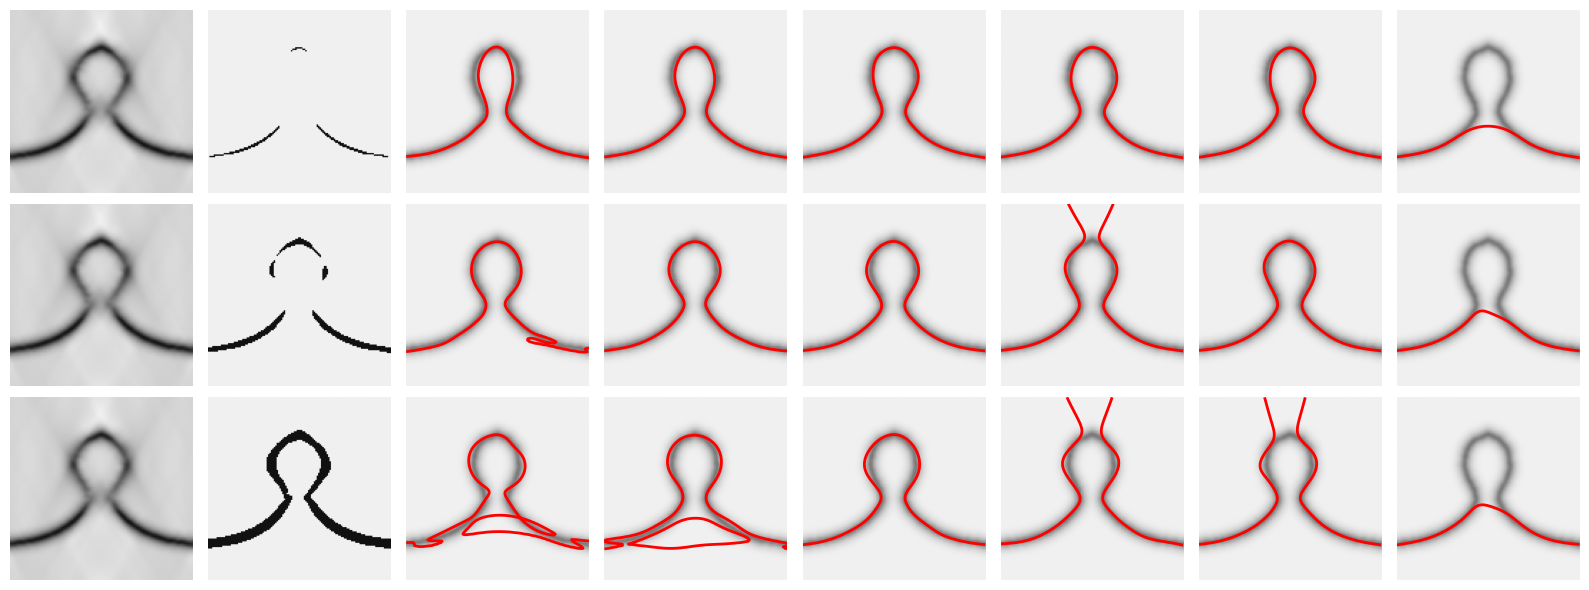

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile
import jax
import jax.numpy as jnp

import jax.experimental.layout as _layout
if not hasattr(_layout, 'DeviceLocalLayout'):
        # Provide a minimal alias so orbax can import function annotations\n",
        _layout.DeviceLocalLayout = _layout.Layout
        print('Patched jax.experimental.layout.DeviceLocalLayout ->', getattr(_layout, 'DeviceLocalLayout'))


GRID_SIZE = 128
lambda_1 = 1000000
lambda_2_list = [0, 10, 30, 50, 100, 1000]
threshold_list = [0.8, 0.6, 0.4]
step = 10000
shape = "bud_04"
wedge_axis= 'y'
flip_ratio = 0.0


# Load checkpoint data
checkpoint_data = {}
for lambda_2 in lambda_2_list:
    checkpoint_data[lambda_2] = {}
    for threshold in threshold_list:
        thre_str = str(threshold).replace('.', '')
        checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/data_0926/m{wedge_axis}-{thre_str}/lambda_{lambda_1}_{lambda_2}")
        checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        checkpoint_data[lambda_2][threshold] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load input data
flip_str = str(flip_ratio).replace('.', '')
input_file = f"../data/synthetic/flip_noise/{shape}_f{flip_str}_w{wedge_axis}.mrc"
with mrcfile.open(input_file, permissive=True) as mrc:
    volume = mrc.data
input_data = volume

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

n = len(lambda_2_list)       # lambda_2 columns
m = len(threshold_list)      # threshold rows
n_col = n+2
fig = plt.figure(figsize=(2*n_col, 2*m))

for i, threshold in enumerate(threshold_list):      # rows

    ax = fig.add_subplot(m, n_col, i * n_col + 1)  # First column in row
    plot_single_slice(input_data, ax=ax, axis="z", slice_index=GRID_SIZE//2, thre=None, show_title=False)

    ax = fig.add_subplot(m, n_col, i * n_col + 2)  # Second column in row
    plot_single_slice(input_data, ax=ax, axis="z", slice_index=GRID_SIZE//2, thre=threshold, show_title=False) 

    for j, lambda_2 in enumerate(lambda_2_list):      # columns
        ax = fig.add_subplot(m, n_col, i * n_col + j + 3)
        data = checkpoint_data[lambda_2][threshold]

        if data is not None:
            visualize_cryoET_with_contours(
                ax, step, data, cryoET_data,
                grid_size=GRID_SIZE, slice_index=64, axis="z", no_label=True
            )
        else:
            ax.axis("off")



plt.tight_layout()
# plt.savefig("../outputs/figs/noise.png", dpi=600, bbox_inches="tight")
plt.show()



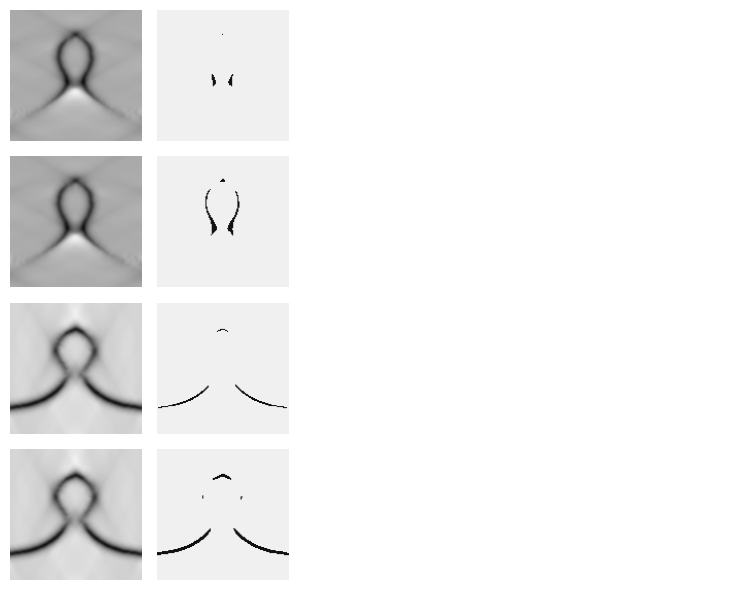

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile

GRID_SIZE = 128
lambda_1 = 1000000
lambda_2_list = [0, 10, 100]
flip_ratio = 0.0
thre_list = [0.8, 0.7]
wedge_axis_list = ['z', 'y']
step = 10000
shape = "bud_04"

# Load checkpoint data
checkpoint_data = {}
for lambda_2 in lambda_2_list:
    checkpoint_data[lambda_2] = {}
    for thre in thre_list:
        flip_str = str(flip_ratio).replace('.', '')
        thre_str = str(thre).replace('.', '')
        checkpoint_data[lambda_2][thre] = {}
        for wedge_axis in wedge_axis_list:            
            checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/flip/f{flip_str}_w{wedge_axis}_{thre_str}/lambda_{lambda_1}_{lambda_2}")
            checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
            checkpoint_data[lambda_2][thre][wedge_axis] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load input data
input_data = {}
flip_str = str(flip_ratio).replace('.', '')
for wedge_axis in wedge_axis_list:
    input_file = f"../data/synthetic/flip_noise/{shape}_f{flip_str}_w{wedge_axis}.mrc"
    with mrcfile.open(input_file, permissive=True) as mrc:
        volume = mrc.data
    input_data[wedge_axis] = volume

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)


n = len(lambda_2_list)                      # columns
m = len(wedge_axis_list) * len(thre_list)   # rows
n_col = n+2
scale = 1.5
fig = plt.figure(figsize=(scale*n_col, scale*m))

row_idx = 0
for w_i, wedge_axis in enumerate(wedge_axis_list):        # outer: wedge axis
    for t_i, thre in enumerate(thre_list):                # inner: threshold
        r = w_i * len(thre_list) + t_i                    # row number (0-based)
        base = r * n_col                                  # starting subplot index in this row

        # --- First column: raw input slice (no threshold) ---
        ax = fig.add_subplot(m, n_col, base + 1)
        plot_single_slice(
            input_data[wedge_axis], 
            ax=ax, axis="z", slice_index=64, thre=None, show_title=False
        )

        # --- Second column: thresholded input slice ---
        ax = fig.add_subplot(m, n_col, base + 2)
        plot_single_slice(
            input_data[wedge_axis], 
            ax=ax, axis="z", slice_index=64, thre=thre, show_title=False
        )

        # --- Remaining columns: results for each lambda_2 ---
        for j, lambda_2 in enumerate(lambda_2_list):
            ax = fig.add_subplot(m, n_col, base + 3 + j)

            # If your checkpoint data is indexed by wedge_axis too, use the 3-key path.
            # Adjust depending on how you stored it:
            data = checkpoint_data[lambda_2][thre][wedge_axis]
            # data = checkpoint_data[lambda_2][thre]  # <- keep if this is your structure

            if data is not None:
                visualize_cryoET_with_contours(
                    ax, step, data, cryoET_data,
                    grid_size=GRID_SIZE, slice_index=64, axis="z", no_label=True
                )
            else:
                ax.axis("off")

        row_idx += 1



plt.tight_layout()
# plt.savefig("../outputs/figs/noise.png", dpi=600, bbox_inches="tight")
plt.show()



/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/multi/data_0926/f015/lambda_1000000_50
Resizing MRC data from (128, 128, 128) to (64, 64, 64)


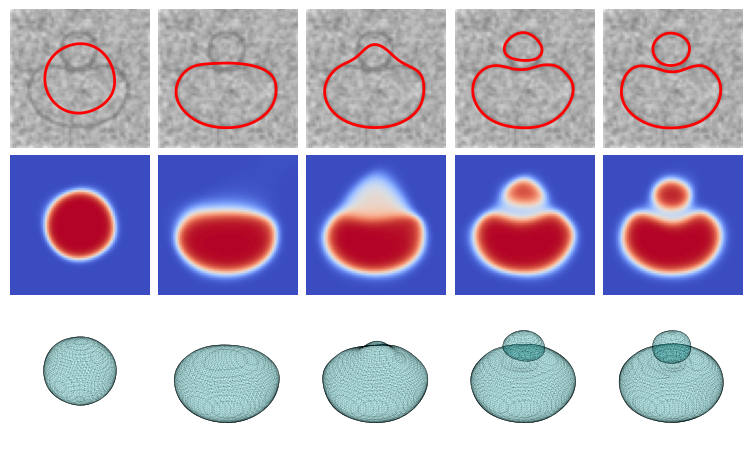

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
lambda_1 = 1000000
lambda_2 = 50
steps_to_visualize = [0, 1200, 2400, 3600, 10000]
epsilon = 0.05
version = "data_0926"
# init_conf = "sphere"
shape = "multi"
axis = "z"
flip_ratio = 0.15
str_flip = str(flip_ratio).replace('.', '')

# Load checkpoint data
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{version}/{init_conf}/lambda_{lambda_1}_{lambda_2}")
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{version}/f{str_flip}/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

n_col = len(steps_to_visualize)
n_row = 3

fig = plt.figure(figsize=(1.5*n_col, 1.5*n_row))

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    # Row 1: visualize_cryoET_with_contours
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(n_row, n_col, i + 1)
        visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis=axis, no_label=True)
    
    # Row 2: phase field
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(n_row, n_col, n_col+i+1)
        visualize_physics_loss(ax, epsilon=epsilon,
                               checkpoint=checkpoint_data[step], component="phi",
                               grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis=axis, vmin=-1, vmax=1, no_label=True)
    
    # Row 3: plot_3d_isosurface
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(n_row, n_col, 2*n_col+i+1, projection='3d')
        plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, no_label=True)
        
    plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/shape_prog_{shape}_{init_conf}_lp{lambda_2}.png", bbox_inches="tight")
    plt.savefig(f"../outputs/figs/sync/shape_prog_{shape}_f{str_flip}_lp{lambda_2}.png", bbox_inches="tight")
    plt.show()


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud/clean/lambda_1000000_10


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


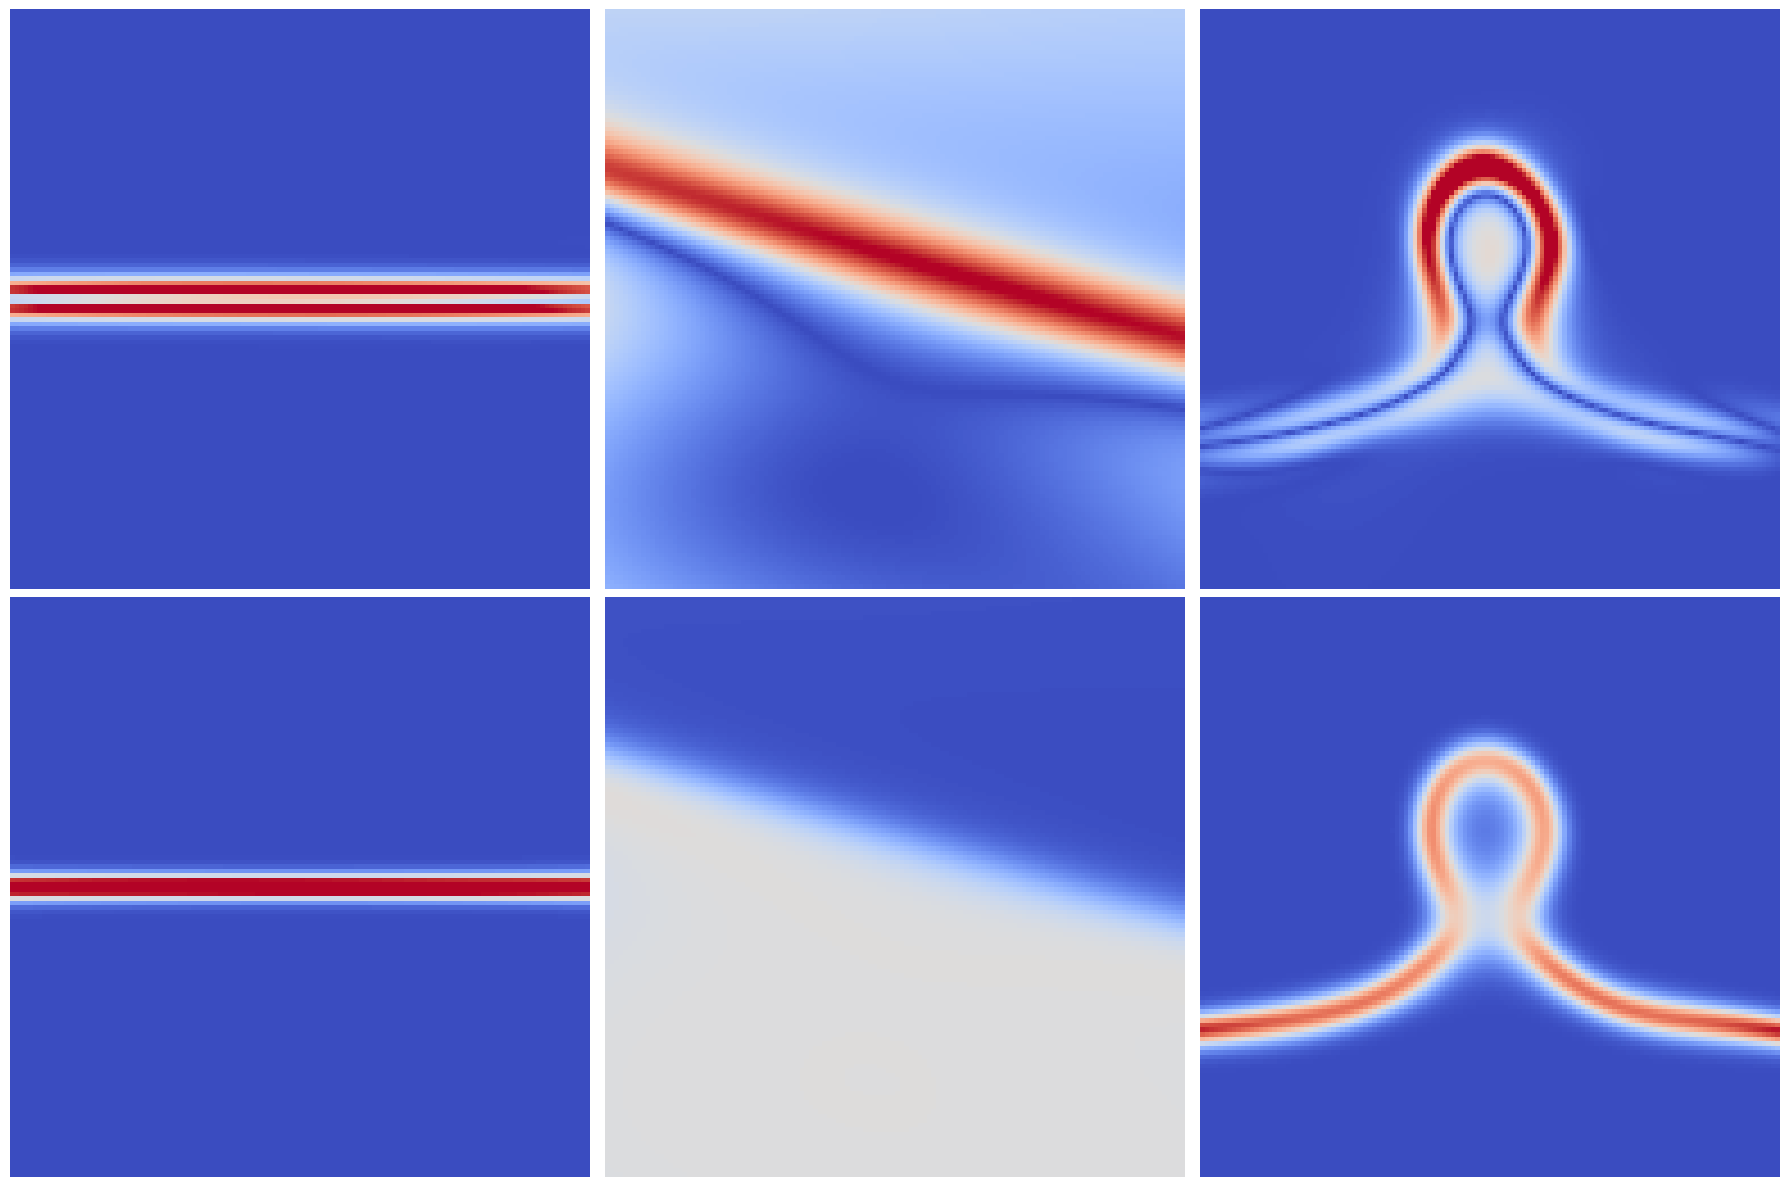

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 128
lambda_1 = 1000000
lambda_2 = 10
steps_to_visualize = [0, 300, 10000]
epsilon = 0.05

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/bud/clean/lambda_{lambda_1}_{lambda_2}")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/base/lambda_{lambda_1}_{lambda_2}")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/biconcave/noisy/flip_015/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = "../data/synthetic/bud.mrc"
# mrc_file_path = "../data/synthetic/biconcave.mrc"
# mrc_file_path = "../data/synthetic/biconcave_noisy_015.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

n_col = len(steps_to_visualize)
n_row = 2

# Plot figures
fig = plt.figure(figsize=(6*n_col, 6*n_row))

# Row 1: data loss
# for i, step in enumerate(steps_to_visualize):
#     ax = fig.add_subplot(n_row, n_col, i + 1)
#     visualize_physics_loss(ax, epsilon=epsilon,
#                            checkpoint=checkpoint_data[step], component="data",
#                            grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=5e-7, no_label=True, cryoET_data=cryoET_data)

# # Row 2: physics loss
# for i, step in enumerate(steps_to_visualize):
#     ax = fig.add_subplot(n_row, n_col, n_col+i+1)
#     visualize_physics_loss(ax, epsilon=epsilon,
#                            checkpoint=checkpoint_data[step], component="residual",
#                            grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=150, no_label=True)

# Row 1: bending energy density
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(n_row, n_col, i + 1)
    visualize_physics_loss(ax, epsilon=epsilon,
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=150, no_label=True)


# Row 2: tension energy density
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(n_row, n_col, n_col+i+1)
    visualize_physics_loss(ax, epsilon=epsilon,
                           checkpoint=checkpoint_data[step], component="tension",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=400, no_label=True)


plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


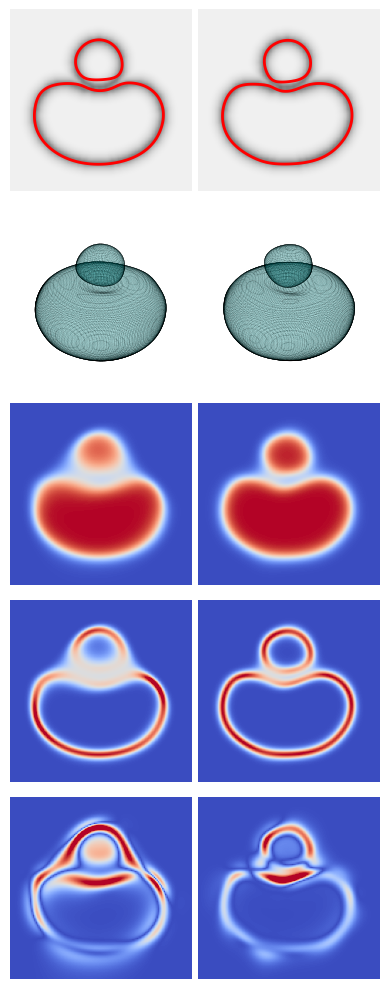

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import (
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    visualize_physics_loss,
)

GRID_SIZE = 128
lambda_1 = 1000000
# lambda_2_list = [0, 10, 100, 1000]
lambda_2_list = [0, 100]
epsilon = 0.05
# shape = "biconcave"
# shape = "bud"
shape = "multi"
noise = "clean"
step = 10000


# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Load checkpoint data
checkpoint_data = {}
for lambda_2 in lambda_2_list:
    checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{noise}/lambda_{lambda_1}_{lambda_2}")
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Plot figures
n_col = len(lambda_2_list)
n_row = 5
scale = 2
fig = plt.figure(figsize=(scale*n_col, scale*n_row))

# Row 1: visualize_cryoET_with_contours
for i, lambda_2 in enumerate(lambda_2_list):
    ax = fig.add_subplot(n_row, n_col, 0*n_col+i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[lambda_2], cryoET_data, grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", no_label=True)

# Row 2: plot_3d_isosurface
for i, lambda_2 in enumerate(lambda_2_list):
    ax = fig.add_subplot(n_row, n_col, 1*n_col+i+1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[lambda_2], grid_size=GRID_SIZE, no_label=True)

# Row 3: phase field
for i, lambda_2 in enumerate(lambda_2_list):
    ax = fig.add_subplot(n_row, n_col, 2*n_col+i+1)
    visualize_physics_loss(ax, epsilon=epsilon,
                           checkpoint=checkpoint_data[lambda_2], component="phi",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=-1, vmax=1, no_label=True)

# Row 4: tension energy
for i, lambda_2 in enumerate(lambda_2_list):
    ax = fig.add_subplot(n_row, n_col, 3*n_col+i+1)
    visualize_physics_loss(ax, epsilon=epsilon,
                           checkpoint=checkpoint_data[lambda_2], component="tension",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=400, no_label=True)

# Row 5: bending energy
for i, lambda_2 in enumerate(lambda_2_list):
    ax = fig.add_subplot(n_row, n_col, 4*n_col+i+1)
    visualize_physics_loss(ax, epsilon=epsilon,
                           checkpoint=checkpoint_data[lambda_2], component="residual",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=150, no_label=True)
    
plt.tight_layout()
plt.savefig(f"../outputs/figs/clean_thin_{shape}.png", dpi=600, bbox_inches="tight")
plt.show()


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import (
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    visualize_physics_loss,
)

GRID_SIZE = 128
lambda_1 = 1000000
lambda_2_list = [0, 100]
epsilon = 0.05
shape = "multi"
noise = "clean"
step = 10000

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Load checkpoint data
checkpoint_data = {}
for lambda_2 in lambda_2_list:
    checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{noise}/lambda_{lambda_1}_{lambda_2}")
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Plot figures
n_col = 5
n_row = len(lambda_2_list)
fig = plt.figure(figsize=(2*n_col, 2*n_row))

for i, lambda_2 in enumerate(lambda_2_list):

    # Col 1: visualize_cryoET_with_contours
    ax = fig.add_subplot(n_row, n_col, n_col*i +1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[lambda_2], cryoET_data, grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", no_label=True)

    # Col 2: plot_3d_isosurface
    ax = fig.add_subplot(n_row, n_col, n_col*i +2, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[lambda_2], grid_size=GRID_SIZE, no_label=True)

    # Col 3: phase field
    ax = fig.add_subplot(n_row, n_col, n_col*i +3)
    visualize_physics_loss(ax, epsilon=epsilon,
                           checkpoint=checkpoint_data[lambda_2], component="phi",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=-1, vmax=1, no_label=True)

    # Col 4: tension energy
    ax = fig.add_subplot(n_row, n_col, n_col*i +4)
    visualize_physics_loss(ax, epsilon=epsilon,
                           checkpoint=checkpoint_data[lambda_2], component="tension",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=400, no_label=True)

    # Col 5: bending energy
    ax = fig.add_subplot(n_row, n_col, n_col*i +5)
    visualize_physics_loss(ax, epsilon=epsilon,
                           checkpoint=checkpoint_data[lambda_2], component="residual",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=150, no_label=True)



plt.tight_layout()
# plt.savefig("your_filename.png", dpi=300, bbox_inches="tight")
plt.show()

Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
Resizing MRC data from (128, 128, 128) to (64, 64, 64)


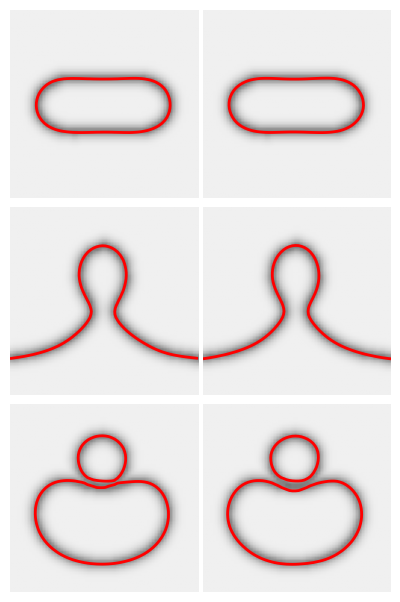

In [8]:
import sys
sys.path.append('../src')

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import visualize_cryoET_with_contours, visualize_physics_loss, plot_3d_isosurface
from data_generation.mesh_to_cryoet import plot_single_slice
import mrcfile
import jax
import jax.numpy as jnp

import jax.experimental.layout as _layout
if not hasattr(_layout, 'DeviceLocalLayout'):
        # Provide a minimal alias so orbax can import function annotations\n",
        _layout.DeviceLocalLayout = _layout.Layout
        print('Patched jax.experimental.layout.DeviceLocalLayout ->', getattr(_layout, 'DeviceLocalLayout'))


GRID_SIZE = 64
lambda_1 = 1000000
# lambda_2_list = [0, 10, 30, 50, 100]
lambda_2_list = [0, 50]
shape_list = ["biconcave", "bud_04", "multi"]
step = 10000
epsilon = 0.05
fig_type = "contour"

# Load checkpoint data
checkpoint_data = {}
for shape in shape_list:
    checkpoint_data[shape] = {}
    for lambda_2 in lambda_2_list:
        checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/data_0926/clean/sphere/lambda_{lambda_1}_{lambda_2}")
        checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        checkpoint_data[shape][lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
if fig_type == "contour":
    cryoET_data = {}
    for shape in shape_list:
        mrc_file_path = f"../data/synthetic/{shape}.mrc"
        cryoET_data[shape] = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

n = len(lambda_2_list)   # lambda_2 columns
m = len(shape_list)      # threshold rows
n_col = n
n_row = m
fig = plt.figure(figsize=(2*n_col, 2*n_row))

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    
    for i, shape in enumerate(shape_list):      # rows
        for j, lambda_2 in enumerate(lambda_2_list):      # columns
            ax = fig.add_subplot(n_row, n_col, i * n_col + j + 1)
            data = checkpoint_data[shape][lambda_2]
    
            if data is not None:
                if fig_type == "contour":
                    visualize_cryoET_with_contours(
                        ax, step, data, cryoET_data[shape],
                        grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis="z", no_label=True)
                elif fig_type == "tension":
                    visualize_physics_loss(ax, epsilon=epsilon,
                                           checkpoint=data, component="tension",
                                           grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis="z", vmin=0, vmax=400, no_label=True)            
                elif fig_type == "bend":
                    visualize_physics_loss(ax, epsilon=epsilon,
                                           checkpoint=data, component="residual",
                                           grid_size=GRID_SIZE, slice_index=GRID_SIZE//2, axis="z", vmin=0, vmax=150, no_label=True)
    
    
    plt.tight_layout()
    # plt.savefig(f"../outputs/figs/sync/dist_plot_{fig_type}.pdf", bbox_inches="tight")
    plt.show()



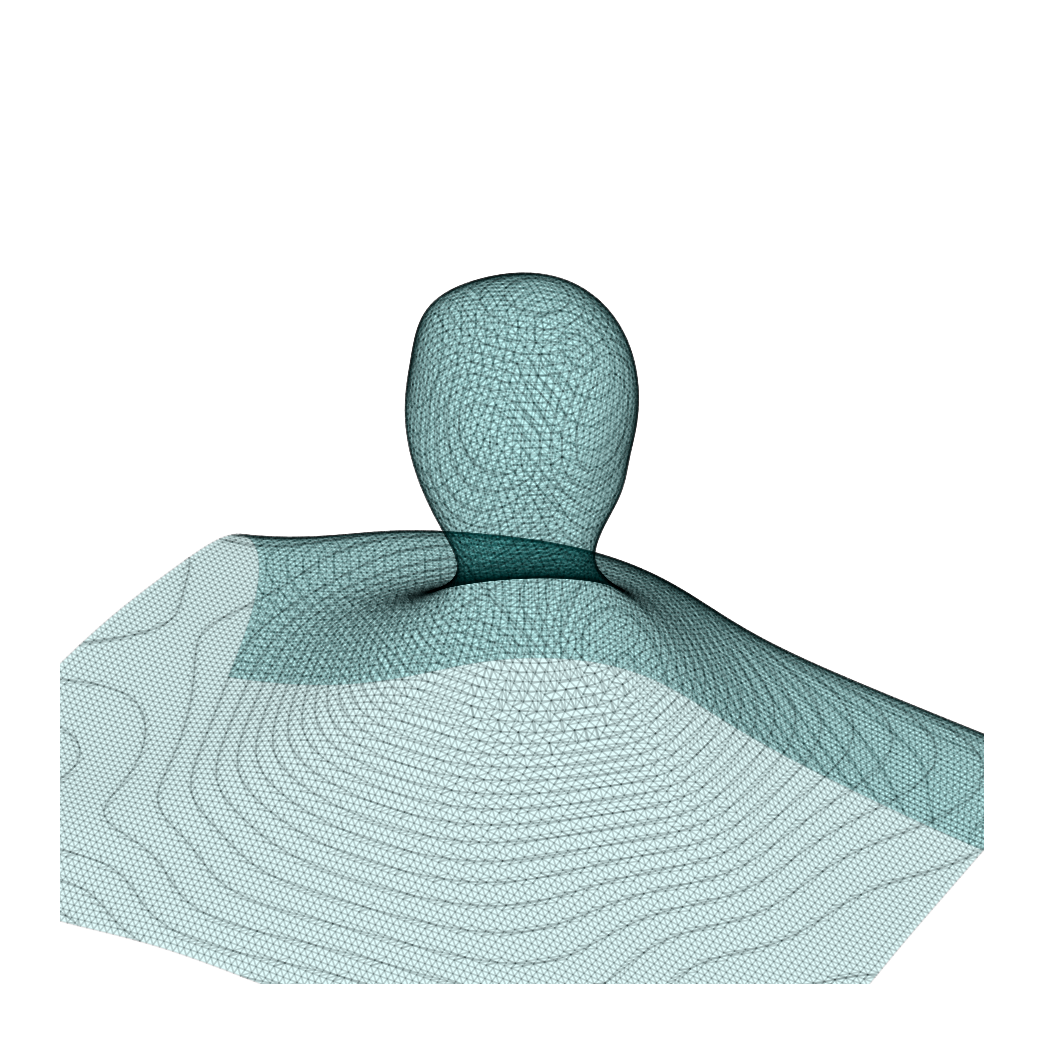

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.plot import (
    visualize_cryoET_with_contours,
    visualize_physics_loss,
    plot_3d_isosurface,
)

GRID_SIZE = 128
lambda_1 = 1000000
lambda_2 = 50
epsilon = 0.05
shape = "bud_04"
step = 10000
# data_type = "data_0926/clean/sphere"
data_type = "data_1115/combine-sphere/a015_m07"

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/lambda_{lambda_1}_{lambda_2}")
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Plot figures
plt.style.reload_library()
with plt.style.context(["base", "transparent"]):

    # fig, ax = plt.subplots(figsize=(2,2))
    fig, ax = plt.subplots(figsize=(2,2), subplot_kw={'projection': '3d'})
    # visualize_cryoET_with_contours(ax, step, checkpoint_data, cryoET_data, grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", no_label=True)
    # visualize_physics_loss(ax, epsilon=epsilon,
    #                        checkpoint=checkpoint_data, component="phi",
    #                        grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=-1, vmax=1, no_label=True)
    plot_3d_isosurface(ax, step, checkpoint_data, grid_size=GRID_SIZE, no_label=True)
    # plt.savefig(f"../outputs/figs/sync/plot_w_contour_{step}.pdf", bbox_inches="tight")
    # plt.savefig(f"../outputs/figs/sync/plot_phi_{step}.pdf", bbox_inches="tight")
    # plt.savefig(f"../outputs/figs/sync/plot_3d_{step}.png", bbox_inches="tight")
    plt.show()
